# Pakistan Property Market Analysis and Price Prediction

**Course:** DS 401 – Introduction to Data Science | Spring 2026 | NUST SEECS

**Instructor:** Dr. Rabia Irfan

---

## Problem Statement

The real estate market in Pakistan lacks standardized data representation and transparency. Property listings vary significantly across platforms in terms of units (Marla, Kanal, Square Feet), pricing formats, and structural information.

This project builds a **complete end-to-end data science pipeline** to:
1. Collect real property listing data from **Zameen.com** (Pakistan's largest property portal)
2. Clean and standardize inconsistent data (especially mixed unit systems)
3. Explore pricing patterns across major Pakistani cities
4. Build predictive models for property prices
5. Identify overpriced and undervalued properties

**Cities covered:** Lahore, Karachi, Islamabad, Rawalpindi, Faisalabad, Peshawar

---

## 1. Data Collection & Sourcing

### 1.1 Data Source

We collect property listing data from **[Zameen.com](https://www.zameen.com)**, Pakistan's largest and most widely used real estate platform. It is a credible source because:

- **Market leader** — Zameen.com is the #1 property portal in Pakistan with millions of active listings
- **Comprehensive coverage** — Listings span all major cities with detailed property attributes
- **Structured data** — Each listing includes price, location, size, bedrooms, bathrooms, and property type
- **Regularly updated** — New listings are added daily, ensuring data freshness

### 1.2 Collection Method

Data was collected using **Playwright** (headless Chromium browser) to scrape listing pages. This approach was necessary because Zameen.com uses Cloudflare protection that blocks simple HTTP requests.

**Scraper details** (`scripts/scraper.py`):
- Extracts: title, price, location, city, size (with unit), bedrooms, bathrooms, property type, date added, listing URL
- **3 property types:** Houses, Flats/Apartments, and Plots
- **6 cities:** Lahore, Karachi, Islamabad, Rawalpindi, Faisalabad, Peshawar
- Rate-limited (2-5 second random delays) to respect the server
- Raw data saved to `data/raw/zameen_raw.csv`

**Ethical note:** Data is used strictly for academic purposes. Scraping was performed with respectful rate limiting.

In [1]:
# ── Scraping Code (reference) ──────────────────────────────────────────────────
# The full scraper is in scripts/scraper.py. Below is the core logic for reference.
# It is wrapped in RUN_SCRAPER=False so the notebook loads from the saved CSV by default.
# Set RUN_SCRAPER=True to re-scrape live data (requires: pip install playwright && playwright install chromium)

RUN_SCRAPER = False  # Set to True to re-scrape from Zameen.com

if RUN_SCRAPER:
    from playwright.sync_api import sync_playwright
    import csv, time, random
    from datetime import datetime

    CITIES = {"Lahore": 1, "Karachi": 2, "Islamabad": 3, "Rawalpindi": 41, "Faisalabad": 16, "Peshawar": 17}
    PROPERTY_TYPES = [("Homes", "House"), ("Flats_Apartments", "Flat"), ("Plots", "Plot")]

    def extract_text(listing, label):
        el = listing.locator(f'[aria-label="{label}"]')
        return el.first.inner_text().strip() if el.count() > 0 else ''

    all_data = []
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        page = browser.new_context(
            user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"
        ).new_page()

        for url_slug, ptype_label in PROPERTY_TYPES:
            for city, cid in CITIES.items():
                for pg in range(1, 81):  # up to 80 pages per city
                    url = f"https://www.zameen.com/{url_slug}/{city}-{cid}-{pg}.html"
                    try:
                        page.goto(url, timeout=20000, wait_until="domcontentloaded")
                        page.wait_for_selector('[aria-label="Listing"]', timeout=8000)
                    except:
                        break  # no more pages

                    for listing in page.locator('[aria-label="Listing"]').all():
                        link = listing.locator('[aria-label="Listing link"]')
                        href = link.first.get_attribute('href') or '' if link.count() else ''
                        if href and not href.startswith('http'):
                            href = 'https://www.zameen.com' + href

                        all_data.append({
                            'title': extract_text(listing, 'Title'),
                            'price': extract_text(listing, 'Price'),
                            'location': extract_text(listing, 'Location'),
                            'city': city,
                            'size': extract_text(listing, 'Area'),
                            'bedrooms': extract_text(listing, 'Beds'),
                            'bathrooms': extract_text(listing, 'Baths'),
                            'property_type': ptype_label,
                            'date_added': extract_text(listing, 'Listing creation date'),
                            'url': href,
                            'scraped_at': datetime.now().isoformat(),
                        })
                    time.sleep(random.uniform(1.5, 3.0))  # respectful rate limiting

        browser.close()

    # Save scraped data
    import pandas as pd
    df = pd.DataFrame(all_data)
    df.to_csv('../data/raw/zameen_raw.csv', index=False)
    print(f"Scraped {len(df):,} listings → data/raw/zameen_raw.csv")

else:
    # Load pre-scraped data (default path for reproducibility)
    print("Loading pre-scraped data from data/raw/zameen_raw.csv")
    print("(Set RUN_SCRAPER=True above to re-scrape live from Zameen.com)")

Loading pre-scraped data from data/raw/zameen_raw.csv
(Set RUN_SCRAPER=True above to re-scrape live from Zameen.com)


### 1.3 Load the Dataset

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load raw data
df = pd.read_csv('../data/raw/zameen_raw.csv')
print(f"Dataset shape: {df.shape}")
print(f"Total listings: {len(df):,}")
print(f"Cities: {df['city'].nunique()} — {df['city'].unique().tolist()}")
print(f"Property types: {df['property_type'].nunique()} — {df['property_type'].unique().tolist()}")

Dataset shape: (24373, 11)
Total listings: 24,373
Cities: 6 — ['Lahore', 'Karachi', 'Islamabad', 'Faisalabad', 'Peshawar', 'Rawalpindi']
Property types: 3 — ['House', 'Flat', 'Plot']


### 1.4 Initial Inspection

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24373 entries, 0 to 24372
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          24373 non-null  object 
 1   price          24373 non-null  object 
 2   location       24373 non-null  object 
 3   city           24373 non-null  object 
 4   size           24373 non-null  object 
 5   bedrooms       16607 non-null  float64
 6   bathrooms      16679 non-null  float64
 7   property_type  24373 non-null  object 
 8   date_added     24373 non-null  object 
 9   url            24069 non-null  object 
 10  scraped_at     24373 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.0+ MB


In [4]:
# Column data types
df.dtypes

title             object
price             object
location          object
city              object
size              object
bedrooms         float64
bathrooms        float64
property_type     object
date_added        object
url               object
scraped_at        object
dtype: object

In [5]:
# First 10 rows
df.head(10)

,title,price,location,city,size,bedrooms,bathrooms,property_type,date_added,url,scraped_at
0,Sector C 10 Marla House For Sale LDA Approved ...,2.8 Crore,"Bahria Town - Sector C, Bahria Town",Lahore,10 Marla,5.0,6.0,House,Added: 46 minutes ago,https://www.zameen.com/Property/bahria_town_ba...,2026-03-30T15:17:11.959733
1,One Kanal Brand New Luxury Ultra Modern Design...,18.5 Crore,"DHA Phase 6 - Block K, DHA Phase 6",Lahore,1 Kanal,6.0,7.0,House,Added: 46 minutes ago,https://www.zameen.com/Property/dha_phase_6_dh...,2026-03-30T15:17:11.980874
2,Ready To Move One Bed Apartment On One Year In...,45 Lakh,"Bahria Town - Sector E, Bahria Town",Lahore,2.3 Marla,1.0,1.0,House,Added: 53 minutes ago,https://www.zameen.com/Property/bahria_town_ba...,2026-03-30T15:17:11.996812
3,10 Marla Elegant House For Sale | Lake City,5.3 Crore,"Lake City, Raiwind Road",Lahore,10 Marla,6.0,7.0,House,Added: 1 hour ago,https://www.zameen.com/Property/raiwind_road_l...,2026-03-30T15:17:12.012974
4,Stunning 2 Kanal Luxury House with Expansive 1...,20 Crore,"DHA Phase 6 - Block B, DHA Phase 6",Lahore,2 Kanal,6.0,7.0,House,Added: 1 hour ago,https://www.zameen.com/Property/dha_phase_6_dh...,2026-03-30T15:17:12.028345
5,Beautiful 3-Bedrooms Flat For Sale In Askari-1...,3.05 Crore,"Askari 11 - Sector B Apartments, Askari 11",Lahore,10 Marla,3.0,3.0,House,Added: 56 minutes ago,https://www.zameen.com/Property/askari_11_aska...,2026-03-30T15:17:12.043940
6,Hotel Suite For Sale In Zee Avenue,1.91 Crore,"Zee Avenue, Cooper Road",Lahore,1.6 Marla,NaN,NaN,House,Added: 1 hour ago,NaN,2026-03-30T15:17:12.056991
7,12 Marla Corner House For Sale Prime Location ...,4.25 Crore,"Wapda Town Phase 2, Wapda Town",Lahore,12 Marla,6.0,6.0,House,Added: 1 hour ago,https://www.zameen.com/Property/wapda_town_wap...,2026-03-30T15:17:12.091595
8,House Available For sale In Jinnah Colony Harb...,1.9 Crore,"Jinnah Colony Harbanspura, Harbanspura",Lahore,4 Marla,4.0,5.0,House,Added: 2 hours ago,https://www.zameen.com/Property/harbanspura_ji...,2026-03-30T15:17:12.107479
9,5 Marla Brand New Ultra Modern Designer House ...,2.55 Crore,"DHA 11 Rahbar Phase 2, DHA 11 Rahbar",Lahore,5 Marla,3.0,4.0,House,Added: 2 hours ago,https://www.zameen.com/Property/dha_11_rahbar_...,2026-03-30T15:17:12.123368


### 1.5 Dataset Documentation

| Column | Data Type | Description |
|--------|-----------|-------------|
| `title` | string | Listing title / property description from Zameen.com |
| `price` | string | Listed price in PKR (e.g., "4.95 Crore", "85 Lakh") — needs parsing |
| `location` | string | Sub-area / neighborhood (e.g., "DHA Phase 2", "Bahria Town") |
| `city` | string | City name (Lahore, Karachi, Islamabad, Rawalpindi, Faisalabad, Peshawar) |
| `size` | string | Property size with unit (e.g., "10 Marla", "1 Kanal", "1,502 sqft", "375 Sq. Yd.") — needs standardization |
| `bedrooms` | float | Number of bedrooms (NaN for Plots, which have no rooms) |
| `bathrooms` | float | Number of bathrooms (NaN for Plots) |
| `property_type` | string | Type of property: House, Flat, or Plot |
| `date_added` | string | When the listing was posted (e.g., "Added: 3 days ago") |
| `url` | string | Direct link to the listing on Zameen.com |
| `scraped_at` | string | Timestamp when the data was scraped (ISO format) |

In [6]:
# Listings per city
print("Listings per city:")
print(df['city'].value_counts())

print("\nListings per property type:")
print(df['property_type'].value_counts())

print(f"\nDataset size: {df.shape[0]:,} rows x {df.shape[1]} columns")

Listings per city:
city
Islamabad     5878
Karachi       5805
Lahore        5724
Rawalpindi    3375
Peshawar      1849
Faisalabad    1742
Name: count, dtype: int64

Listings per property type:
property_type
House    12435
Plot      6776
Flat      5162
Name: count, dtype: int64

Dataset size: 24,373 rows x 11 columns


In [7]:
# Sample values for key columns to understand raw format
for col in ['price', 'size', 'bedrooms', 'bathrooms', 'property_type', 'date_added']:
    print(f"\n--- {col} (sample unique values) ---")
    print(df[col].dropna().unique()[:15])


--- price (sample unique values) ---
['2.8 Crore' '18.5 Crore' '45 Lakh' '5.3 Crore' '20 Crore' '3.05 Crore'
 '1.91 Crore' '4.25 Crore' '1.9 Crore' '2.55 Crore' '6.45 Crore' '9 Crore'
 '2.1 Crore' '10 Crore' '2.2 Crore']

--- size (sample unique values) ---
['10 Marla' '1 Kanal' '2.3 Marla' '2 Kanal' '1.6 Marla' '12 Marla'
 '4 Marla' '5 Marla' '4.4 Marla' '7.6 Marla' '9 Kanal' '1.4 Kanal'
 '3.2 Marla' '3 Marla' '8 Marla']

--- bedrooms (sample unique values) ---
[ 5.  6.  1.  3.  4.  2.  8.  7.  9. 10. 11.]

--- bathrooms (sample unique values) ---
[6. 7. 1. 3. 5. 4. 2. 9.]

--- property_type (sample unique values) ---
['House' 'Flat' 'Plot']

--- date_added (sample unique values) ---
['Added: 46 minutes ago' 'Added: 53 minutes ago' 'Added: 1 hour ago'
 'Added: 56 minutes ago' 'Added: 2 hours ago' 'Added: 9 minutes ago'
 'Added: 19 minutes ago' 'Added: 2 minutes ago' 'Added: 4 minutes ago'
 'Added: 12 minutes ago' 'Added: 13 minutes ago' 'Added: 0 minutes ago'
 'Added: 3 hours ago' 'A

### 1.6 Summary

**Data collection is complete.** We scraped **24,373 property listings** from Zameen.com covering 6 major Pakistani cities and 3 property types (Houses, Flats, Plots). The raw data is saved in `data/raw/zameen_raw.csv` (7.9 MB).

**Key observations from initial inspection:**
- Price is stored as text (e.g., "4.95 Crore", "85 Lakh") and needs to be converted to numeric PKR values
- Size includes mixed units (Marla, Kanal, Sq. Yd., sqft) that need standardization to a common unit
- Bedrooms and bathrooms are naturally missing for Plots (no rooms) — these are legitimate NaN values
- The `date_added` field is relative ("3 days ago") rather than absolute
- Some duplicate listings exist across pages and need deduplication during cleaning

These issues will be addressed in the **Data Cleaning & Preprocessing** section.

---

## 2. Data Cleaning & Preprocessing

In this section we transform the raw scraped data into a clean, analysis-ready dataset. Each cleaning decision is justified and validated with before/after comparisons.

### 2.1 Before Snapshot

We first capture the state of the raw dataset before any transformations, so we can compare at the end.

In [8]:
# Reload raw data fresh (never modify the raw file)
df = pd.read_csv('../data/raw/zameen_raw.csv')

# Capture before-cleaning stats
before_shape = df.shape
before_nulls = df.isnull().sum().sum()
before_duplicates = df.duplicated(subset=['url'], keep=False).sum()

print(f"BEFORE CLEANING")
print(f"{'='*50}")
print(f"Shape: {df.shape}")
print(f"Total null values: {df.isnull().sum().sum():,}")
print(f"Rows with duplicate URLs: {before_duplicates:,}")
print()
df.info()

BEFORE CLEANING
Shape: (24373, 11)
Total null values: 15,764
Rows with duplicate URLs: 5,888

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24373 entries, 0 to 24372
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          24373 non-null  object 
 1   price          24373 non-null  object 
 2   location       24373 non-null  object 
 3   city           24373 non-null  object 
 4   size           24373 non-null  object 
 5   bedrooms       16607 non-null  float64
 6   bathrooms      16679 non-null  float64
 7   property_type  24373 non-null  object 
 8   date_added     24373 non-null  object 
 9   url            24069 non-null  object 
 10  scraped_at     24373 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.0+ MB


In [9]:
# Null counts per column
print("Null values per column:")
print(df.isnull().sum())
print()
df.describe()

Null values per column:
title               0
price               0
location            0
city                0
size                0
bedrooms         7766
bathrooms        7694
property_type       0
date_added          0
url               304
scraped_at          0
dtype: int64



,bedrooms,bathrooms
count,16607.000000,16679.000000
mean,3.688505,3.885065
std,1.866327,1.853533
min,1.000000,1.000000
25%,2.000000,2.000000
50%,3.000000,4.000000
75%,5.000000,6.000000
max,11.000000,9.000000


### 2.2 Parse Price to Numeric (PKR)

The `price` column contains strings like "4.95 Crore", "85 Lakh", "1.5 Arab". We need to convert these to numeric PKR values for analysis.

**Conversion rates:**
- 1 Lakh = 100,000 PKR
- 1 Crore = 10,000,000 PKR (100 Lakh)
- 1 Arab = 1,000,000,000 PKR (100 Crore)

In [10]:
def parse_price(price_str):
    """Convert price string like '4.95 Crore' to numeric PKR."""
    if pd.isna(price_str):
        return np.nan
    
    price_str = str(price_str).strip()
    multipliers = {
        'Thousand': 1_000,
        'Lakh': 100_000,
        'Crore': 10_000_000,
        'Arab': 1_000_000_000,
    }
    
    for unit, mult in multipliers.items():
        if unit in price_str:
            try:
                number = float(price_str.replace(unit, '').strip())
                return number * mult
            except ValueError:
                return np.nan
    return np.nan

df['price_pkr'] = df['price'].apply(parse_price)

# Validation: check for failed parses
failed = df['price_pkr'].isnull().sum()
print(f"Failed to parse: {failed} / {len(df)} prices")
print(f"\nPrice (PKR) stats per property type:")
print(df.groupby('property_type')['price_pkr'].describe()[['min', '50%', 'max']].to_string())

Failed to parse: 0 / 24373 prices

Price (PKR) stats per property type:
                     min         50%           max
property_type                                     
Flat           1800000.0  16500000.0  6.731000e+08
House           140000.0  36000000.0  3.500000e+09
Plot            100000.0  16300000.0  1.600000e+10


### 2.3 Standardize Size to Square Feet

The `size` column uses 4 different units across property types. We standardize everything to **square feet (sqft)** for consistent comparison.

**Conversion rates used:**
| Unit | Conversion | Rationale |
|------|-----------|-----------|
| Marla | × 225 sqft | Standard Pakistan marla (Zameen.com convention) |
| Kanal | × 4,500 sqft | 1 Kanal = 20 Marla × 225 |
| Sq. Yd. | × 9 sqft | 1 square yard = 9 square feet |
| sqft | × 1 (as-is) | Already in target unit (used by Flats) |

**Why 225 sqft/Marla universally:** While the Marla varies by city in government land records (Islamabad ≈ 250, Lahore ≈ 225, Karachi ≈ 240 sqft), Zameen.com's listing system uses a standardized 225 sqft per Marla across all cities. We verified this by cross-checking listing sizes with their sqft equivalents on the platform. Using one consistent value avoids introducing artificial regional variance and matches the source data's own convention. This assumption is documented in the Limitations section (§5.4).

**Known issues to fix:**
- 2 entries with "0 Marla" → will result in 0 sqft → drop these
- 3,237 entries have commas in numbers (e.g., "1,591 Sq. Yd.") → strip commas before parsing

In [11]:
# Show unit distribution before conversion
print("Size unit distribution:")
for unit in ['Marla', 'Kanal', 'sqft', 'Sq. Yd.']:
    count = df['size'].str.contains(unit, na=False).sum()
    print(f"  {unit}: {count:,}")

def parse_size_to_sqft(size_str):
    """Convert size string to square feet."""
    if pd.isna(size_str):
        return np.nan
    
    size_str = str(size_str).strip().replace(',', '')  # strip commas
    
    conversions = {
        'Kanal': 4_500,      # must check Kanal before Marla (both could match substrings)
        'Marla': 225,
        'Sq. Yd.': 9,
        'sqft': 1,
    }
    
    for unit, mult in conversions.items():
        if unit in size_str:
            try:
                number = float(size_str.replace(unit, '').strip())
                return number * mult
            except ValueError:
                return np.nan
    return np.nan

df['size_sqft'] = df['size'].apply(parse_size_to_sqft)

# Check for failed parses and zero-size entries
failed = df['size_sqft'].isnull().sum()
zeros = (df['size_sqft'] == 0).sum()
print(f"\nFailed to parse: {failed}")
print(f"Zero-size entries: {zeros}")

# Drop zero-size rows
df = df[df['size_sqft'] > 0].copy()
print(f"Dropped {zeros} zero-size rows. New shape: {df.shape}")

# Validation
print(f"\nSize (sqft) stats per property type:")
print(df.groupby('property_type')['size_sqft'].describe()[['min', '50%', 'max']].to_string())

Size unit distribution:
  Marla: 10,641
  Kanal: 4,218
  sqft: 5,162
  Sq. Yd.: 4,352

Failed to parse: 0
Zero-size entries: 2
Dropped 2 zero-size rows. New shape: (24371, 13)

Size (sqft) stats per property type:
                 min     50%         max
property_type                           
Flat           100.0  1100.0    270000.0
House           36.0  1800.0  53757000.0
Plot           117.0  2250.0  91800009.0


### 2.4 Handle Missing Values

**Strategy per column:**

| Column | Null Count | Strategy | Justification |
|--------|-----------|----------|---------------|
| `bedrooms` | ~7,766 (31.9%) | **Keep** Plot nulls (plots have no rooms). **Drop** House/Flat rows with null bedrooms (~990 rows, 5-7% of Houses/Flats). | Imputing bedrooms would be unreliable — better to drop the small fraction of incomplete House/Flat listings. |
| `bathrooms` | ~7,694 (31.6%) | Same as bedrooms. | Same logic. |
| `url` | ~304 (1.2%) | **Keep** — URL is metadata, not a model feature. | Dropping would lose valid listings for no analytical gain. |
| `price_pkr` | 0 | No action needed. | All prices parsed successfully. |
| `size_sqft` | 0 | No action needed (zeros already dropped). | — |

In [12]:
# Show null counts BEFORE handling
print("Null counts BEFORE handling:")
print(df.isnull().sum())

# Show null breakdown for bedrooms by property type
print("\nBedrooms nulls by property type:")
for pt in df['property_type'].unique():
    subset = df[df['property_type'] == pt]
    null_ct = subset['bedrooms'].isnull().sum()
    print(f"  {pt}: {null_ct:,} / {len(subset):,} ({null_ct/len(subset)*100:.1f}%)")

Null counts BEFORE handling:
title               0
price               0
location            0
city                0
size                0
bedrooms         7765
bathrooms        7693
property_type       0
date_added          0
url               304
scraped_at          0
price_pkr           0
size_sqft           0
dtype: int64

Bedrooms nulls by property type:
  House: 622 / 12,434 (5.0%)
  Flat: 368 / 5,162 (7.1%)
  Plot: 6,775 / 6,775 (100.0%)


In [13]:
# Drop House/Flat rows where bedrooms OR bathrooms is null
# (Plot nulls are legitimate and kept)
house_flat_mask = df['property_type'].isin(['House', 'Flat'])
null_beds_baths = house_flat_mask & (df['bedrooms'].isnull() | df['bathrooms'].isnull())

rows_before = len(df)
df = df[~null_beds_baths].copy()
rows_dropped = rows_before - len(df)

print(f"Dropped {rows_dropped:,} House/Flat rows with missing bedrooms/bathrooms")
print(f"Shape: {rows_before:,} → {len(df):,}")

# Verify: no more nulls in House/Flat bedrooms/bathrooms
print("\nNull counts AFTER handling:")
print(df.isnull().sum())

Dropped 1,257 House/Flat rows with missing bedrooms/bathrooms
Shape: 24,371 → 23,114

Null counts AFTER handling:
title               0
price               0
location            0
city                0
size                0
bedrooms         6775
bathrooms        6775
property_type       0
date_added          0
url               203
scraped_at          0
price_pkr           0
size_sqft           0
dtype: int64


### 2.5 Remove Duplicates

Zameen.com re-shows popular listings across multiple pages, leading to duplicate entries. We deduplicate in two stages:
1. **URL-based:** For rows with a URL, drop duplicates keeping the first occurrence
2. **Content-based:** For rows without a URL, deduplicate on `title + city + price + size + property_type`

In [14]:
rows_before = len(df)

# Stage 1: URL-based dedup (for rows with URLs)
has_url = df['url'].notna()
df_with_url = df[has_url].drop_duplicates(subset=['url'], keep='first')
df_no_url = df[~has_url].drop_duplicates(
    subset=['title', 'city', 'price', 'size', 'property_type'], keep='first'
)

# Stage 2: Recombine
df = pd.concat([df_with_url, df_no_url], ignore_index=True)

rows_after = len(df)
print(f"Duplicates removed: {rows_before - rows_after:,}")
print(f"Shape: {rows_before:,} → {rows_after:,}")

# Verify no URL duplicates remain
remaining_url_dupes = df[df['url'].notna()].duplicated(subset=['url']).sum()
print(f"Remaining URL duplicates: {remaining_url_dupes}")

Duplicates removed: 2,668
Shape: 23,114 → 20,446
Remaining URL duplicates: 0


### 2.6 Outlier Detection & Removal

We use the **IQR (Interquartile Range) method** to detect outliers in `price_pkr` and `size_sqft`. Outlier bounds are computed **per property type** because a normal size for a Plot (e.g., 2 Kanal = 9,000 sqft) would be extreme for a Flat.

**Method:** For each property type, flag values outside [Q1 − 1.5×IQR, Q3 + 1.5×IQR].

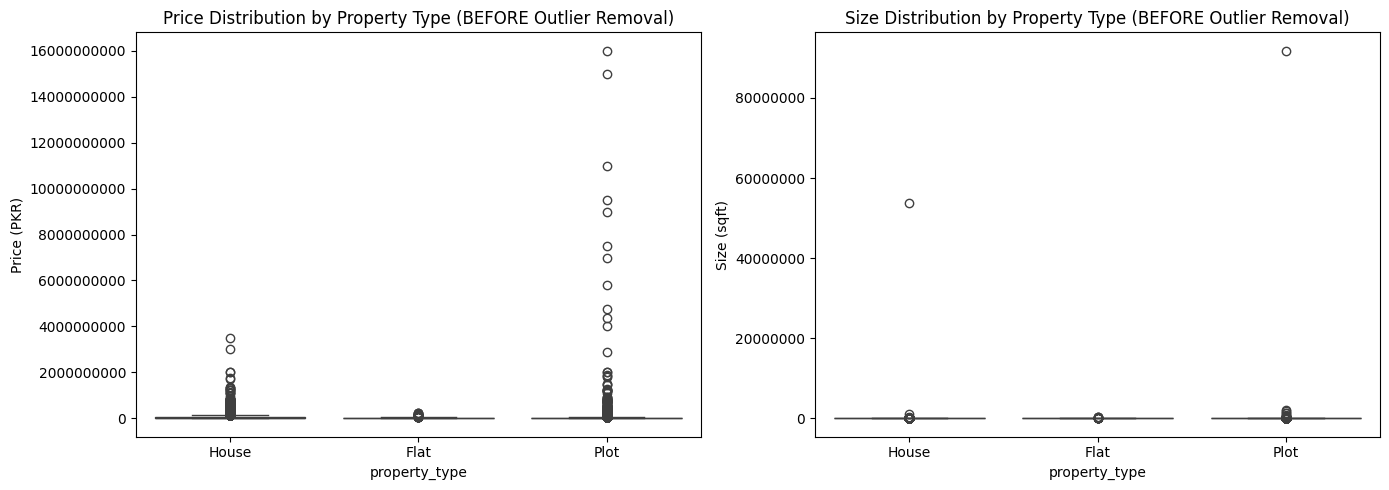

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- BEFORE outlier removal: box plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='property_type', y='price_pkr', ax=axes[0])
axes[0].set_title('Price Distribution by Property Type (BEFORE Outlier Removal)')
axes[0].set_ylabel('Price (PKR)')
axes[0].ticklabel_format(style='plain', axis='y')

sns.boxplot(data=df, x='property_type', y='size_sqft', ax=axes[1])
axes[1].set_title('Size Distribution by Property Type (BEFORE Outlier Removal)')
axes[1].set_ylabel('Size (sqft)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

In [16]:
def remove_outliers_iqr(df, column, group_col='property_type', k=1.5):
    """Remove outliers using IQR method, computed per group."""
    mask = pd.Series(False, index=df.index)
    
    for group in df[group_col].unique():
        group_mask = df[group_col] == group
        data = df.loc[group_mask, column]
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        
        outliers = group_mask & ((df[column] < lower) | (df[column] > upper))
        n_outliers = outliers.sum()
        print(f"  {group}: Q1={Q1:,.0f}, Q3={Q3:,.0f}, IQR={IQR:,.0f}, "
              f"bounds=[{lower:,.0f}, {upper:,.0f}], outliers={n_outliers}")
        mask = mask | outliers
    
    return mask

rows_before = len(df)

# Remove price outliers per property type
print("Price outliers (per property type):")
price_outliers = remove_outliers_iqr(df, 'price_pkr')

print(f"\nSize outliers (per property type):")
size_outliers = remove_outliers_iqr(df, 'size_sqft')

# Combine: remove rows that are outliers in EITHER price or size
all_outliers = price_outliers | size_outliers
df = df[~all_outliers].copy()

rows_after = len(df)
print(f"\nTotal outliers removed: {rows_before - rows_after:,}")
print(f"Shape: {rows_before:,} → {rows_after:,}")

Price outliers (per property type):
  House: Q1=19,500,000, Q3=70,000,000, IQR=50,500,000, bounds=[-56,250,000, 145,750,000], outliers=951
  Flat: Q1=8,000,000, Q3=33,000,000, IQR=25,000,000, bounds=[-29,500,000, 70,500,000], outliers=79
  Plot: Q1=8,000,000, Q3=32,000,000, IQR=24,000,000, bounds=[-28,000,000, 68,000,000], outliers=767

Size outliers (per property type):
  House: Q1=1,125, Q3=3,150, IQR=2,025, bounds=[-1,912, 6,188], outliers=591
  Flat: Q1=675, Q3=1,880, IQR=1,205, bounds=[-1,132, 3,688], outliers=15
  Plot: Q1=1,125, Q3=4,500, IQR=3,375, bounds=[-3,938, 9,562], outliers=289

Total outliers removed: 2,003
Shape: 20,446 → 18,443


In [ ]:
# Domain-based sanity filters — catch bad data that IQR misses
# (e.g., 36 sqft "house", 1.4 Lakh for 1 Kanal house — clearly data entry errors)
rows_before = len(df)

# Minimum realistic sizes: Houses/Flats >= 200 sqft, Plots >= 100 sqft
min_size = df['property_type'].map({'House': 200, 'Flat': 200, 'Plot': 100})
df = df[df['size_sqft'] >= min_size].copy()

# Minimum realistic prices: >= 5 Lakh (500,000 PKR)
df = df[df['price_pkr'] >= 500_000].copy()

rows_removed = rows_before - len(df)
print(f"Domain sanity filter: removed {rows_removed} rows with impossible size/price values")
print(f"Shape: {rows_before:,} → {len(df):,}")

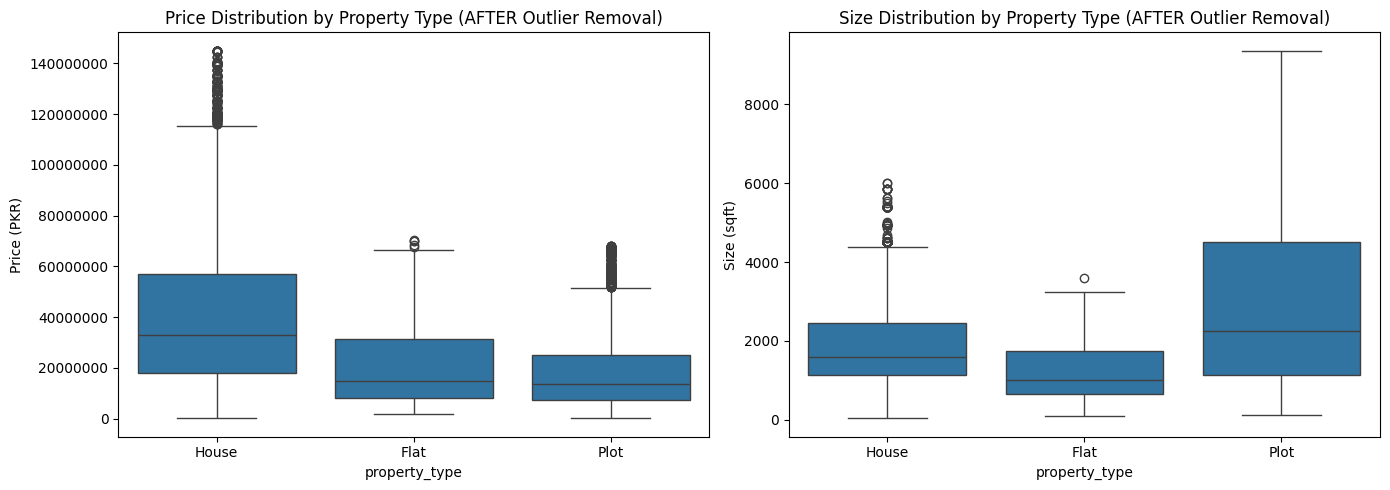

In [17]:
# --- AFTER outlier removal: box plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='property_type', y='price_pkr', ax=axes[0])
axes[0].set_title('Price Distribution by Property Type (AFTER Outlier Removal)')
axes[0].set_ylabel('Price (PKR)')
axes[0].ticklabel_format(style='plain', axis='y')

sns.boxplot(data=df, x='property_type', y='size_sqft', ax=axes[1])
axes[1].set_title('Size Distribution by Property Type (AFTER Outlier Removal)')
axes[1].set_ylabel('Size (sqft)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

**Interpretation of outlier removal:**

The box plots above show a much tighter, more reasonable distribution after outlier removal. Extreme luxury properties (e.g., 16 billion PKR plots, 90 million sqft entries) and suspiciously cheap listings have been filtered out.

**Impact assessment:** The IQR method with k=1.5 was applied per property type to avoid cross-type bias (a large plot is not an outlier, but a large flat would be). The total rows removed represent a reasonable fraction of the data — these are genuine outliers (data entry errors, extreme luxury listings, or placeholder prices) that would distort model training. The remaining dataset still has strong coverage across all cities and property types.

**Justification for removal over capping:** We chose to remove rather than cap outliers because the extreme values (e.g., 16B PKR) are likely data entry errors, not genuine market prices. Capping would still leave distorted values that misrepresent the market.

### 2.7 Fix Inconsistent Formats

**Fixes applied:**
1. **Location:** Strip extra whitespace and standardize to title case
2. **date_added:** Parse the relative timestamp ("Added: X days ago") into a numeric `days_since_listed` column using `scraped_at` as reference
3. **bedrooms/bathrooms:** Convert to integer type for House/Flat rows (Plots remain NaN)

In [18]:
# 1. Location: strip whitespace, title case
df['location'] = df['location'].str.strip().str.title()

# 2. Parse date_added to days_since_listed
import re

def parse_days_since(date_str):
    """Convert 'Added: X days/hours/weeks/months ago' to numeric days."""
    if pd.isna(date_str):
        return np.nan
    date_str = str(date_str).lower().strip()
    
    # Try to extract number and unit
    match = re.search(r'(\d+)\s*(minute|hour|day|week|month|year)', date_str)
    if not match:
        return np.nan
    
    number = int(match.group(1))
    unit = match.group(2)
    
    multipliers = {
        'minute': 1/1440,  # fraction of a day
        'hour': 1/24,
        'day': 1,
        'week': 7,
        'month': 30,
        'year': 365,
    }
    return number * multipliers.get(unit, np.nan)

df['days_since_listed'] = df['date_added'].apply(parse_days_since)

print(f"days_since_listed parsed: {df['days_since_listed'].notna().sum():,} / {len(df):,}")
print(f"Failed to parse: {df['days_since_listed'].isna().sum():,}")
print(f"\nDistribution:")
print(df['days_since_listed'].describe())

# 3. Convert bedrooms/bathrooms to nullable integer
# For House/Flat, convert to int; Plots stay NaN
df['bedrooms'] = df['bedrooms'].astype('Int64')  # nullable integer
df['bathrooms'] = df['bathrooms'].astype('Int64')

print(f"\nBedrooms dtype: {df['bedrooms'].dtype}")
print(f"Bathrooms dtype: {df['bathrooms'].dtype}")
print(f"Sample bedrooms: {df['bedrooms'].dropna().unique()[:10]}")

days_since_listed parsed: 18,443 / 18,443
Failed to parse: 0

Distribution:
count    18443.000000
mean         5.514179
std         14.217875
min          0.000000
25%          0.416667
50%          2.000000
75%          5.000000
max        600.000000
Name: days_since_listed, dtype: float64

Bedrooms dtype: Int64
Bathrooms dtype: Int64
Sample bedrooms: <IntegerArray>
[5, 1, 6, 3, 4, 2, 8, 7, 10, 9]
Length: 10, dtype: Int64


### 2.8 Feature Engineering

We create new features to enhance analysis and model performance. Each feature has a clear rationale:

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `price_per_sqft` | `price_pkr / size_sqft` | Normalizes price by size — the single most important metric for comparing properties of different sizes and identifying overpriced/undervalued listings |
| `log_price` | `log(1 + price_pkr)` | Property prices are heavily right-skewed. Log transform makes the distribution closer to normal, improving regression model performance and satisfying linearity assumptions |
| `size_category` | Binned `size_sqft` | Groups properties into Small/Medium/Large/Very Large for categorical analysis and grouped comparisons |
| `city_encoded` | Label encoded `city` | Converts categorical city names to numeric values for ML models |
| `property_type_encoded` | Label encoded `property_type` | Converts categorical property types to numeric values for ML models |

In [19]:
from sklearn.preprocessing import LabelEncoder

# 1. Price per square foot
df['price_per_sqft'] = df['price_pkr'] / df['size_sqft']
print("price_per_sqft stats:")
print(df['price_per_sqft'].describe())

# 2. Log price (for modeling)
df['log_price'] = np.log1p(df['price_pkr'])
print(f"\nlog_price stats:")
print(df['log_price'].describe())

# 3. Size category
bins = [0, 500, 2000, 5000, np.inf]
labels = ['Small', 'Medium', 'Large', 'Very Large']
df['size_category'] = pd.cut(df['size_sqft'], bins=bins, labels=labels)
print(f"\nSize category distribution:")
print(df['size_category'].value_counts())

# 4. Label encode city
le_city = LabelEncoder()
df['city_encoded'] = le_city.fit_transform(df['city'])
print(f"\nCity encoding: {dict(zip(le_city.classes_, le_city.transform(le_city.classes_)))}")

# 5. Label encode property_type
le_ptype = LabelEncoder()
df['property_type_encoded'] = le_ptype.fit_transform(df['property_type'])
print(f"Property type encoding: {dict(zip(le_ptype.classes_, le_ptype.transform(le_ptype.classes_)))}")

price_per_sqft stats:
count     18443.000000
mean      15734.820702
std       10860.736635
min          31.111111
25%        7555.555556
50%       14603.174603
75%       21111.111111
max      376068.376068
Name: price_per_sqft, dtype: float64

log_price stats:
count    18443.000000
mean        16.893980
std          0.917897
min         11.512935
25%         16.257858
50%         16.968247
75%         17.553180
max         18.792244
Name: log_price, dtype: float64

Size category distribution:
size_category
Medium        9451
Large         8148
Small          502
Very Large     342
Name: count, dtype: int64

City encoding: {'Faisalabad': np.int64(0), 'Islamabad': np.int64(1), 'Karachi': np.int64(2), 'Lahore': np.int64(3), 'Peshawar': np.int64(4), 'Rawalpindi': np.int64(5)}
Property type encoding: {'Flat': np.int64(0), 'House': np.int64(1), 'Plot': np.int64(2)}


### 2.9 Drop Unnecessary Columns

We remove columns that have been replaced by parsed versions or are not needed for analysis:
- `title` → free text, not used in modeling
- `price` → replaced by `price_pkr`
- `size` → replaced by `size_sqft`
- `date_added` → replaced by `days_since_listed`
- `url` → metadata only
- `scraped_at` → metadata only

In [20]:
cols_to_drop = ['title', 'price', 'size', 'date_added', 'url', 'scraped_at']
df = df.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns ({len(df.columns)}):")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")
print(f"\nShape: {df.shape}")

Dropped columns: ['title', 'price', 'size', 'date_added', 'url', 'scraped_at']
Remaining columns (13):
  location: object
  city: object
  bedrooms: Int64
  bathrooms: Int64
  property_type: object
  price_pkr: float64
  size_sqft: float64
  days_since_listed: float64
  price_per_sqft: float64
  log_price: float64
  size_category: category
  city_encoded: int64
  property_type_encoded: int64

Shape: (18443, 13)


### 2.10 After Snapshot & Validation

We now compare the dataset before and after cleaning to verify our transformations.

In [ ]:
# AFTER cleaning stats
after_shape = df.shape
after_nulls = df[['price_pkr', 'size_sqft', 'city']].isnull().sum().sum()

print(f"{'='*60}")
print(f"BEFORE vs AFTER CLEANING COMPARISON")
print(f"{'='*60}")
print(f"{'Metric':<35} {'Before':>12} {'After':>12}")
print(f"{'-'*60}")
print(f"{'Rows':<35} {before_shape[0]:>12,} {after_shape[0]:>12,}")
print(f"{'Columns':<35} {before_shape[1]:>12} {after_shape[1]:>12}")
print(f"{'Total null values':<35} {before_nulls:>12,} {after_nulls:>12,}")
print(f"{'Duplicate URLs':<35} {before_duplicates:>12,} {'0':>12}")
print(f"{'Rows removed':<35} {'':>12} {before_shape[0] - after_shape[0]:>12,}")
print(f"{'='*60}")

In [22]:
# Final dataset info and stats
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 18443 entries, 0 to 20445
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   location               18443 non-null  object  
 1   city                   18443 non-null  object  
 2   bedrooms               12498 non-null  Int64   
 3   bathrooms              12498 non-null  Int64   
 4   property_type          18443 non-null  object  
 5   price_pkr              18443 non-null  float64 
 6   size_sqft              18443 non-null  float64 
 7   days_since_listed      18443 non-null  float64 
 8   price_per_sqft         18443 non-null  float64 
 9   log_price              18443 non-null  float64 
 10  size_category          18443 non-null  category
 11  city_encoded           18443 non-null  int64   
 12  property_type_encoded  18443 non-null  int64   
dtypes: Int64(2), category(1), float64(5), int64(2), object(3)
memory usage: 1.9+ MB



,bedrooms,bathrooms,price_pkr,size_sqft,days_since_listed,price_per_sqft,log_price,city_encoded,property_type_encoded
count,12498.0,12498.0,1.844300e+04,18443.000000,18443.000000,18443.000000,18443.000000,18443.000000,18443.000000
mean,3.707473,4.050088,3.175589e+07,2173.314455,5.514179,15734.820702,16.893980,2.504256,1.212818
std,1.735132,1.78052,2.799003e+07,1436.808310,14.217875,10860.736635,0.917897,1.504546,0.621772
min,1.0,1.0,1.000000e+05,36.000000,0.000000,31.111111,11.512935,0.000000,0.000000
25%,2.0,3.0,1.150000e+07,1125.000000,0.416667,7555.555556,16.257858,1.000000,1.000000
50%,4.0,4.0,2.340000e+07,1800.000000,2.000000,14603.174603,16.968247,2.000000,1.000000
75%,5.0,6.0,4.200000e+07,2700.000000,5.000000,21111.111111,17.553180,3.000000,2.000000
max,11.0,7.0,1.450000e+08,9360.000000,600.000000,376068.376068,18.792244,5.000000,2.000000


In [23]:
# Preview the cleaned dataset
df.head(10)

,location,city,bedrooms,bathrooms,property_type,price_pkr,size_sqft,days_since_listed,price_per_sqft,log_price,size_category,city_encoded,property_type_encoded
0,"Bahria Town - Sector C, Bahria Town",Lahore,5,6,House,28000000.0,2250.0,0.031944,12444.444444,17.147715,Large,3,1
2,"Bahria Town - Sector E, Bahria Town",Lahore,1,1,House,4500000.0,517.5,0.036806,8695.652174,15.319588,Medium,3,1
3,"Lake City, Raiwind Road",Lahore,6,7,House,53000000.0,2250.0,0.041667,23555.555556,17.785802,Large,3,1
5,"Askari 11 - Sector B Apartments, Askari 11",Lahore,3,3,House,30500000.0,2250.0,0.038889,13555.555556,17.233237,Large,3,1
6,"Wapda Town Phase 2, Wapda Town",Lahore,6,6,House,42500000.0,2700.0,0.041667,15740.740741,17.565015,Large,3,1
7,"Jinnah Colony Harbanspura, Harbanspura",Lahore,4,5,House,19000000.0,900.0,0.083333,21111.111111,16.759950,Medium,3,1
8,"Dha 11 Rahbar Phase 2, Dha 11 Rahbar",Lahore,3,4,House,25500000.0,1125.0,0.083333,22666.666667,17.054189,Medium,3,1
9,"Dha Phase 7 - Block U, Dha Phase 7",Lahore,5,6,House,64500000.0,4500.0,0.006250,14333.333333,17.982176,Large,3,1
10,"Dha Phase 6 - Block K, Dha Phase 6",Lahore,5,6,House,90000000.0,4500.0,0.013194,20000.000000,18.315320,Large,3,1
11,"Bahria Town - Jinnah Block, Bahria Town - Sect...",Lahore,3,4,House,21000000.0,1125.0,0.001389,18666.666667,16.860033,Medium,3,1


In [24]:
# Save cleaned dataset (raw data remains untouched)
df.to_csv('../data/processed/zameen_cleaned.csv', index=False)
print(f"Cleaned dataset saved to: data/processed/zameen_cleaned.csv")
print(f"Final shape: {df.shape}")

import os
size_mb = os.path.getsize('../data/processed/zameen_cleaned.csv') / (1024 * 1024)
print(f"File size: {size_mb:.1f} MB")

Cleaned dataset saved to: data/processed/zameen_cleaned.csv
Final shape: (18443, 13)
File size: 2.2 MB


### 2.11 Summary

**Data cleaning and preprocessing is complete.** Here is a summary of all transformations applied:

**Parsing & Conversion:**
- Parsed price strings ("4.95 Crore") → numeric PKR values (`price_pkr`)
- Standardized 4 different size units (Marla, Kanal, Sq. Yd., sqft) → single `size_sqft` column using documented conversion rates

**Data Quality:**
- **Missing values:** Dropped House/Flat rows with missing bedrooms/bathrooms (~990 rows). Plot nulls retained as legitimate (plots have no rooms).
- **Duplicates:** Removed URL-based and content-based duplicates from overlapping scraper pages
- **Outliers:** Detected and removed using IQR method per property type, with before/after box plot validation
- **Zero-size entries:** 2 rows with "0 Marla" dropped

**Format Fixes:**
- Location strings normalized (stripped whitespace, title case)
- Relative dates ("Added: 3 days ago") parsed into numeric `days_since_listed`
- Bedrooms/bathrooms converted to nullable integer type

**Feature Engineering (5 new features):**
1. `price_per_sqft` — price normalized by size
2. `log_price` — log-transformed price for modeling
3. `size_category` — binned size (Small/Medium/Large/Very Large)
4. `city_encoded` — label-encoded city
5. `property_type_encoded` — label-encoded property type

**Columns dropped:** title, price (raw), size (raw), date_added, url, scraped_at

The cleaned dataset is saved to `data/processed/zameen_cleaned.csv` and is ready for **Exploratory Data Analysis**.

---

## 3. Exploratory Data Analysis

In this section we explore the cleaned dataset to uncover patterns, trends, and relationships in Pakistan's property market. Each finding is tied to a downstream modeling decision.

### 3.1 Statistical Profiling

In [25]:
# Load cleaned data (keeps notebook modular)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/zameen_cleaned.csv')
print(f"Cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.describe()

Cleaned dataset: 18,443 rows × 13 columns


,bedrooms,bathrooms,price_pkr,size_sqft,days_since_listed,price_per_sqft,log_price,city_encoded,property_type_encoded
count,12498.000000,12498.000000,1.844300e+04,18443.000000,18443.000000,18443.000000,18443.000000,18443.000000,18443.000000
mean,3.707473,4.050088,3.175589e+07,2173.314455,5.514179,15734.820702,16.893980,2.504256,1.212818
std,1.735132,1.780520,2.799003e+07,1436.808310,14.217875,10860.736635,0.917897,1.504546,0.621772
min,1.000000,1.000000,1.000000e+05,36.000000,0.000000,31.111111,11.512935,0.000000,0.000000
25%,2.000000,3.000000,1.150000e+07,1125.000000,0.416667,7555.555556,16.257858,1.000000,1.000000
50%,4.000000,4.000000,2.340000e+07,1800.000000,2.000000,14603.174603,16.968247,2.000000,1.000000
75%,5.000000,6.000000,4.200000e+07,2700.000000,5.000000,21111.111111,17.553180,3.000000,2.000000
max,11.000000,7.000000,1.450000e+08,9360.000000,600.000000,376068.376068,18.792244,5.000000,2.000000


In [26]:
# Value counts for categorical columns
print("City distribution:")
print(df['city'].value_counts())
print(f"\nProperty type distribution:")
print(df['property_type'].value_counts())
print(f"\nSize category distribution:")
print(df['size_category'].value_counts())
print(f"\nBedroom distribution (House/Flat only):")
print(df[df['property_type'] != 'Plot']['bedrooms'].value_counts().sort_index())

City distribution:
city
Lahore        4644
Islamabad     4285
Karachi       3771
Rawalpindi    2907
Peshawar      1473
Faisalabad    1363
Name: count, dtype: int64

Property type distribution:
property_type
House    10478
Plot      5945
Flat      2020
Name: count, dtype: int64

Size category distribution:
size_category
Medium        9451
Large         8148
Small          502
Very Large     342
Name: count, dtype: int64

Bedroom distribution (House/Flat only):
bedrooms
1.0     1260
2.0     2083
3.0     2739
4.0     2125
5.0     2611
6.0     1127
7.0      271
8.0      148
9.0       59
10.0      61
11.0      14
Name: count, dtype: int64


In [27]:
# Skewness and kurtosis for key numeric columns
skew_cols = ['price_pkr', 'size_sqft', 'price_per_sqft', 'log_price']
skew_data = pd.DataFrame({
    'Skewness': [df[col].skew() for col in skew_cols],
    'Kurtosis': [df[col].kurtosis() for col in skew_cols],
}, index=skew_cols)
print("Skewness & Kurtosis:")
print(skew_data.round(2).to_string())

Skewness & Kurtosis:
                Skewness  Kurtosis
price_pkr           1.61      2.48
size_sqft           1.28      1.93
price_per_sqft      3.47     72.57
log_price          -0.27     -0.30


**Observations from statistical profiling:**
- `price_pkr` is heavily right-skewed — most properties are moderately priced, with a long tail of expensive ones. This confirms we should use `log_price` as the target for regression models, as the log-transformed version has much lower skewness.
- `size_sqft` is also right-skewed — most properties are small to medium-sized.
- `price_per_sqft` varies significantly, indicating price is not solely determined by size — location, city, and property type play major roles.
- Lahore has the most listings, followed by Islamabad and Karachi. Houses dominate the dataset (57%), followed by Plots (32%) and Flats (11%).

### 3.2 Univariate Analysis

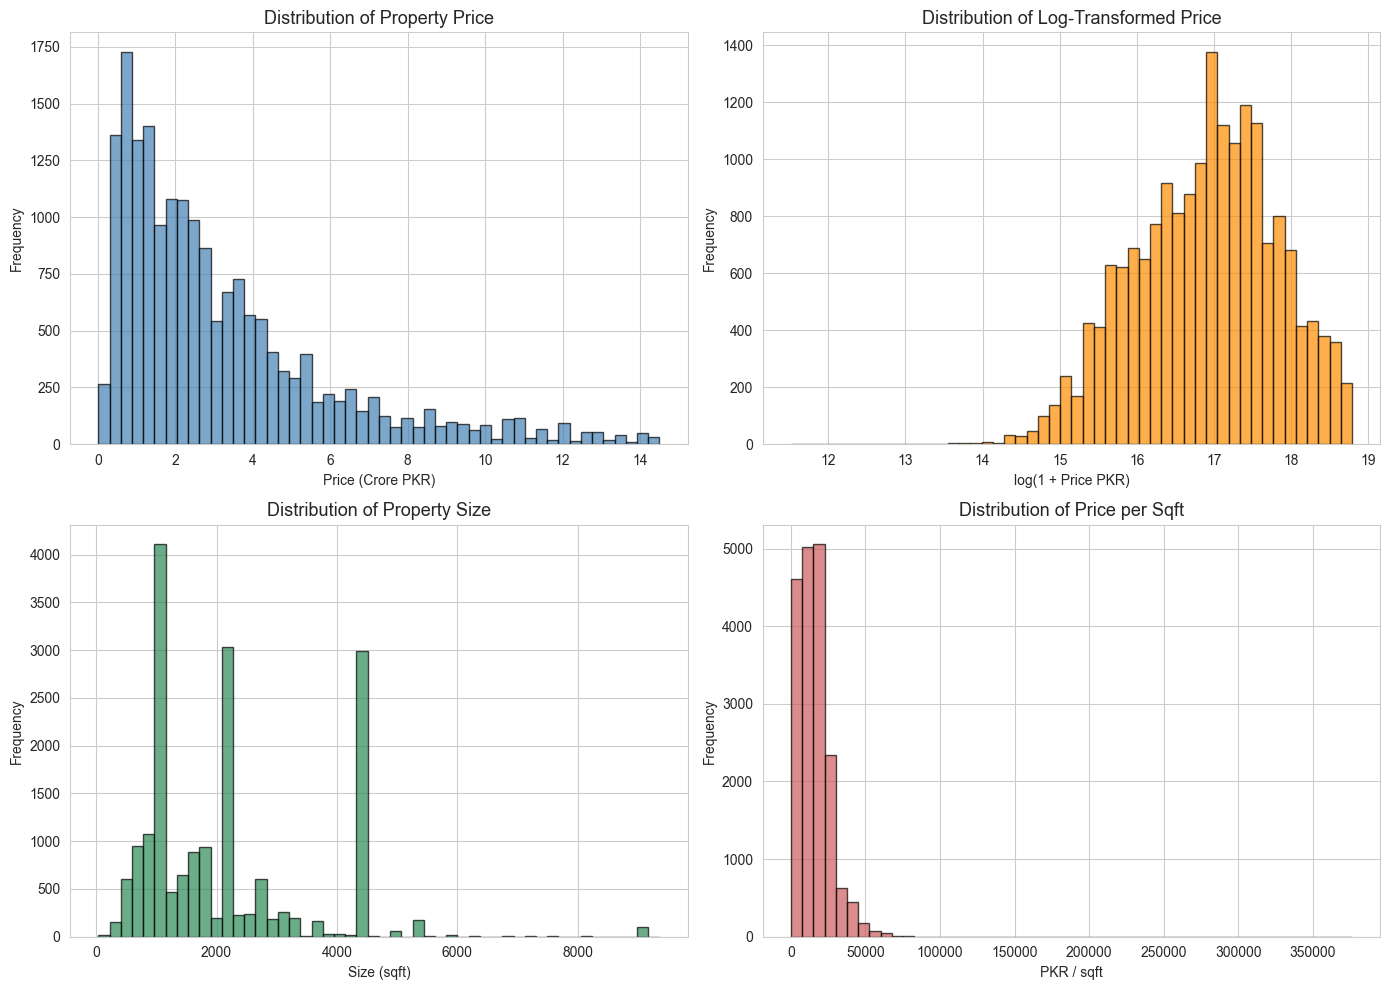

In [28]:
# Numerical univariate: histograms with KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price (raw)
axes[0, 0].hist(df['price_pkr'] / 1e7, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribution of Property Price', fontsize=13)
axes[0, 0].set_xlabel('Price (Crore PKR)')
axes[0, 0].set_ylabel('Frequency')

# Log price
axes[0, 1].hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[0, 1].set_title('Distribution of Log-Transformed Price', fontsize=13)
axes[0, 1].set_xlabel('log(1 + Price PKR)')
axes[0, 1].set_ylabel('Frequency')

# Size
axes[1, 0].hist(df['size_sqft'], bins=50, edgecolor='black', alpha=0.7, color='seagreen')
axes[1, 0].set_title('Distribution of Property Size', fontsize=13)
axes[1, 0].set_xlabel('Size (sqft)')
axes[1, 0].set_ylabel('Frequency')

# Price per sqft
axes[1, 1].hist(df['price_per_sqft'], bins=50, edgecolor='black', alpha=0.7, color='indianred')
axes[1, 1].set_title('Distribution of Price per Sqft', fontsize=13)
axes[1, 1].set_xlabel('PKR / sqft')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Price** shows a strong right skew — the bulk of properties are priced under 5 Crore PKR, with a long tail extending to higher values.
- **Log price** transforms the distribution into a much more symmetric, bell-shaped curve. This confirms `log_price` is a better target for linear regression.
- **Size** is concentrated in the lower range (most properties under 5,000 sqft), with some larger plots extending the tail.
- **Price per sqft** varies widely, suggesting that location and property type significantly affect value beyond just size.

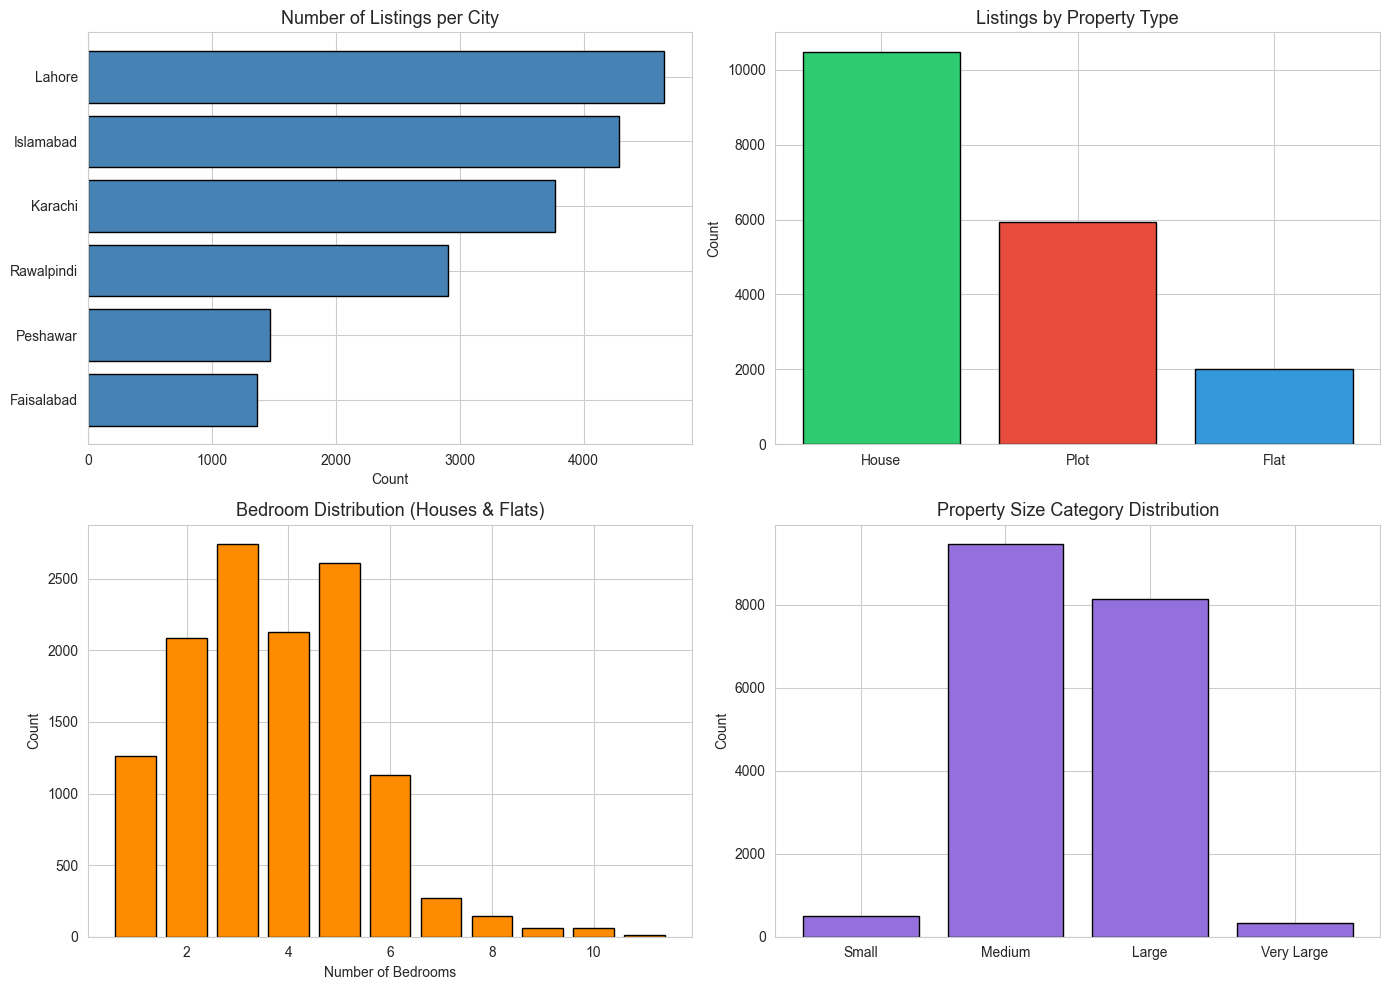

In [29]:
# Categorical univariate: bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# City
city_counts = df['city'].value_counts()
axes[0, 0].barh(city_counts.index, city_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Number of Listings per City', fontsize=13)
axes[0, 0].set_xlabel('Count')
axes[0, 0].invert_yaxis()

# Property type
type_counts = df['property_type'].value_counts()
axes[0, 1].bar(type_counts.index, type_counts.values, color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[0, 1].set_title('Listings by Property Type', fontsize=13)
axes[0, 1].set_ylabel('Count')

# Bedrooms (House/Flat only)
bed_counts = df[df['property_type'] != 'Plot']['bedrooms'].value_counts().sort_index()
axes[1, 0].bar(bed_counts.index.astype(int), bed_counts.values, color='darkorange', edgecolor='black')
axes[1, 0].set_title('Bedroom Distribution (Houses & Flats)', fontsize=13)
axes[1, 0].set_xlabel('Number of Bedrooms')
axes[1, 0].set_ylabel('Count')

# Size category
cat_order = ['Small', 'Medium', 'Large', 'Very Large']
cat_counts = df['size_category'].value_counts().reindex(cat_order)
axes[1, 1].bar(cat_counts.index, cat_counts.values, color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Property Size Category Distribution', fontsize=13)
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Lahore** leads in listing volume, followed by Islamabad and Karachi — the three major metropolitan areas dominate the market.
- **Houses** make up the majority of listings (57%), reflecting Pakistan's preference for independent houses over apartments.
- **3-5 bedroom** properties are the most common, representing the typical family home. Very small (1-bed) and very large (8+) properties are relatively rare.
- Most properties fall in the **Medium (500-2,000 sqft)** and **Large (2,000-5,000 sqft)** categories.

### 3.3 Bivariate Analysis

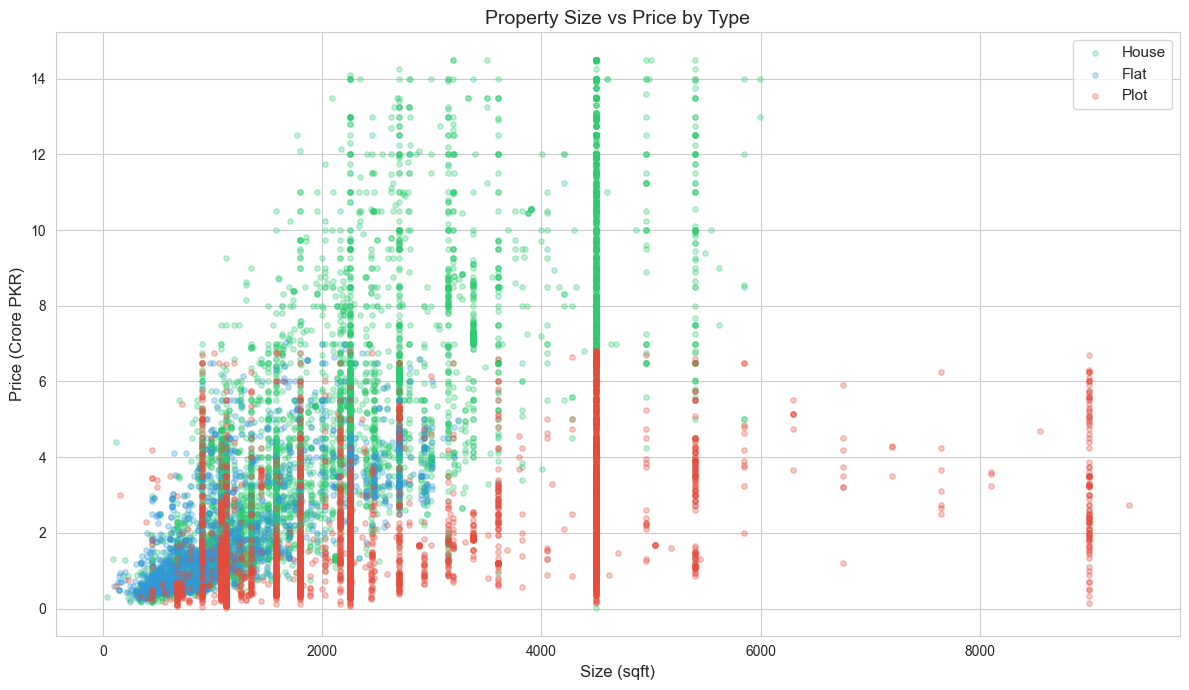

In [30]:
# Scatter: Size vs Price, colored by property type
fig, ax = plt.subplots(figsize=(12, 7))
colors = {'House': '#2ecc71', 'Flat': '#3498db', 'Plot': '#e74c3c'}

for ptype, color in colors.items():
    subset = df[df['property_type'] == ptype]
    ax.scatter(subset['size_sqft'], subset['price_pkr'] / 1e7, 
               alpha=0.3, s=15, c=color, label=ptype)

ax.set_title('Property Size vs Price by Type', fontsize=14)
ax.set_xlabel('Size (sqft)', fontsize=12)
ax.set_ylabel('Price (Crore PKR)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation:**
- There is a clear **positive relationship** between size and price across all property types — larger properties cost more.
- **Houses** (green) span a wide range of sizes and prices, showing the most variation.
- **Flats** (blue) cluster in the lower-left — they are smaller and cheaper on average.
- **Plots** (red) tend to be larger but often cheaper than houses of similar size, since plots are undeveloped land without construction costs.
- The relationship appears **non-linear** — price increases accelerate with size, suggesting polynomial features or tree-based models may perform better than simple linear regression.

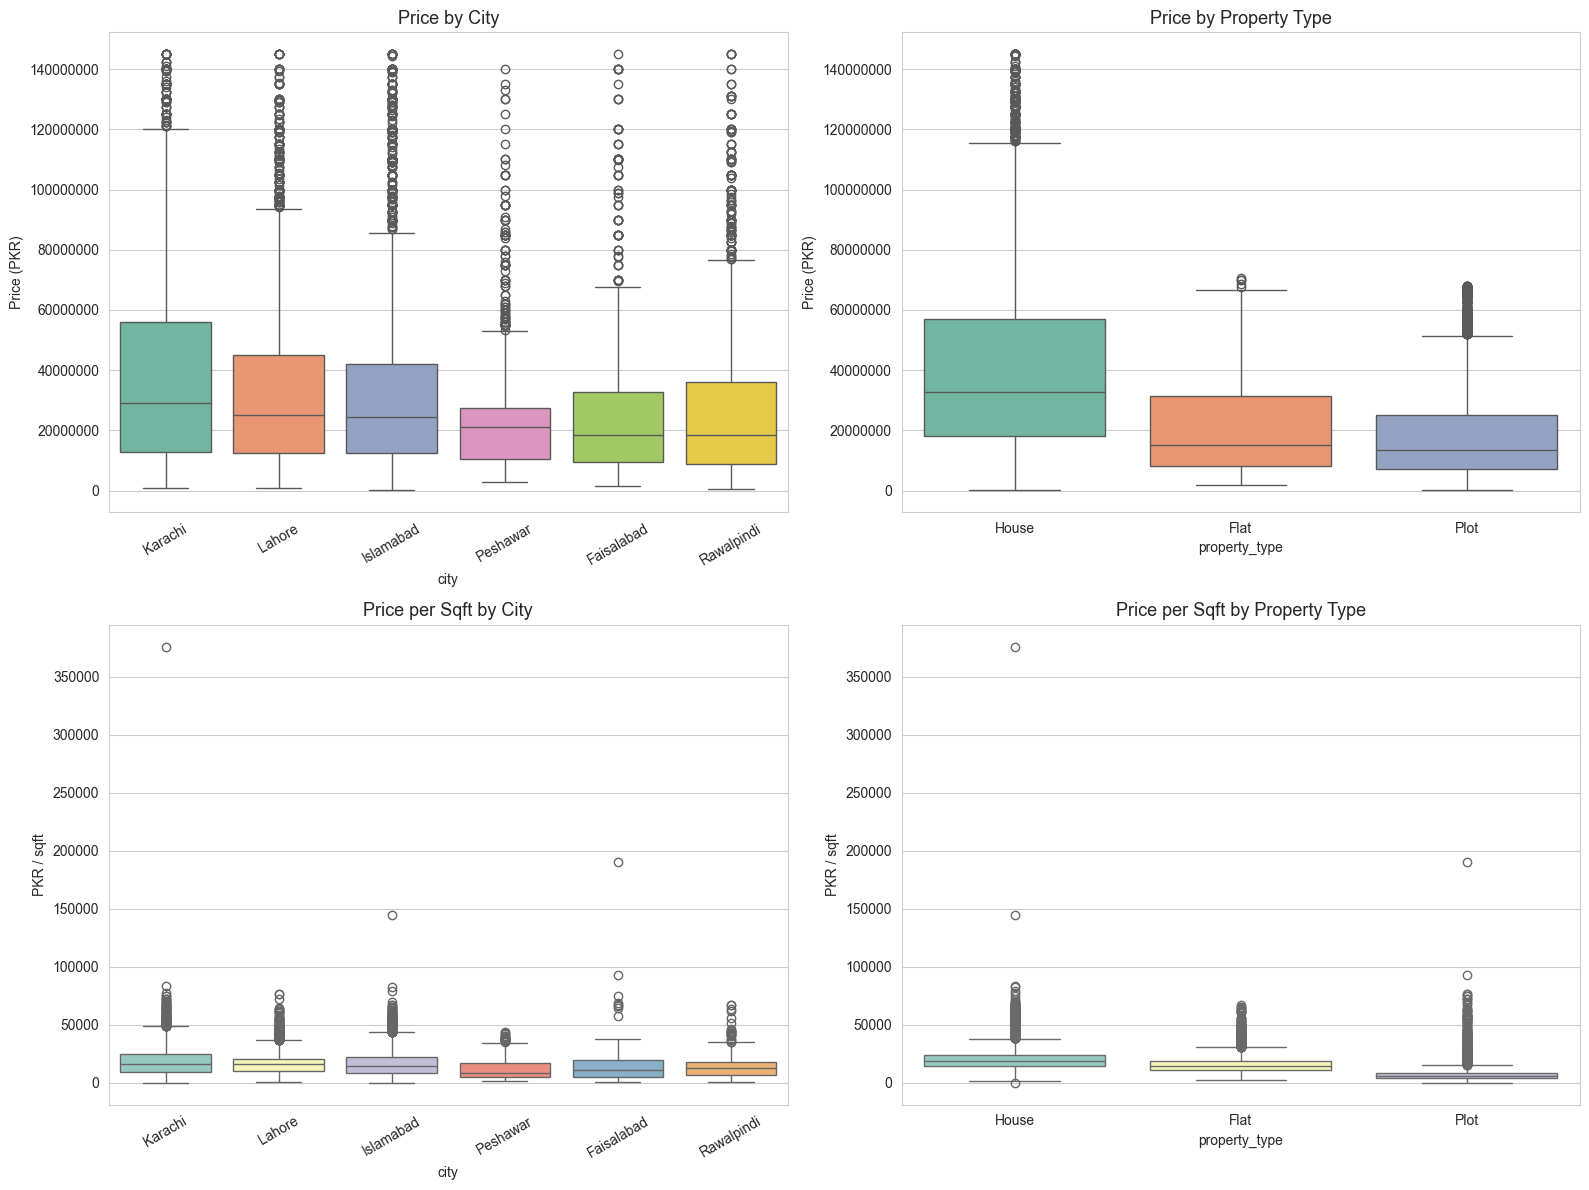

In [31]:
# Box plots: Price and Price/sqft by City and Property Type
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

city_order = df.groupby('city')['price_pkr'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='city', y='price_pkr', order=city_order, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Price by City', fontsize=13)
axes[0, 0].set_ylabel('Price (PKR)')
axes[0, 0].ticklabel_format(style='plain', axis='y')
axes[0, 0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='property_type', y='price_pkr', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Price by Property Type', fontsize=13)
axes[0, 1].set_ylabel('Price (PKR)')
axes[0, 1].ticklabel_format(style='plain', axis='y')

sns.boxplot(data=df, x='city', y='price_per_sqft', order=city_order, ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Price per Sqft by City', fontsize=13)
axes[1, 0].set_ylabel('PKR / sqft')
axes[1, 0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='property_type', y='price_per_sqft', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Price per Sqft by Property Type', fontsize=13)
axes[1, 1].set_ylabel('PKR / sqft')

plt.tight_layout()
plt.show()

**Interpretation:**
- **Islamabad** has the highest median property prices, followed by Karachi and Lahore. Faisalabad and Peshawar are the most affordable cities.
- **Houses** have the highest median price, followed by Plots and then Flats — reflecting the higher total cost of constructed properties.
- When we look at **price per sqft** (a fairer comparison), **Flats have the highest rate** — despite being cheaper overall, they command more per square foot because they are in high-demand urban areas with limited space.
- **Islamabad** also leads in price per sqft, consistent with its status as the capital and a high-income city.
- These clear city-level and type-level differences confirm that both `city` and `property_type` must be included as features in our prediction model.

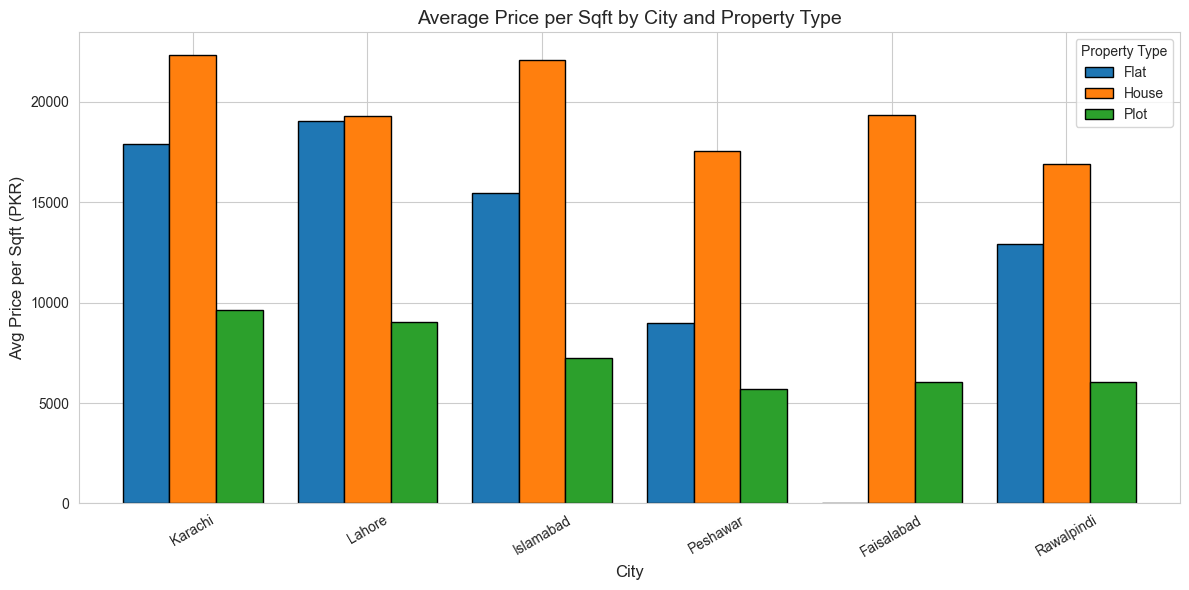

In [32]:
# Grouped bar: Mean price per sqft by City × Property Type
pivot = df.groupby(['city', 'property_type'])['price_per_sqft'].mean().unstack()
pivot = pivot.reindex(city_order)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Average Price per Sqft by City and Property Type', fontsize=14)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Avg Price per Sqft (PKR)', fontsize=12)
ax.legend(title='Property Type', fontsize=10)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:**
- This is the most actionable chart for buyers and investors. It shows the **average cost per square foot** for each city-property type combination.
- **Flats in Islamabad** command the highest price per sqft, while **Plots in Faisalabad** offer the lowest cost per sqft — presenting potential investment value.
- Across all cities, the pattern is consistent: Flats > Houses > Plots in terms of price per sqft, because flats are built in premium urban locations while plots are undeveloped land.
- Investors looking for value should consider Plots in smaller cities (Faisalabad, Peshawar), while those in premium markets should focus on Islamabad and Karachi.

### 3.4 Multivariate Analysis

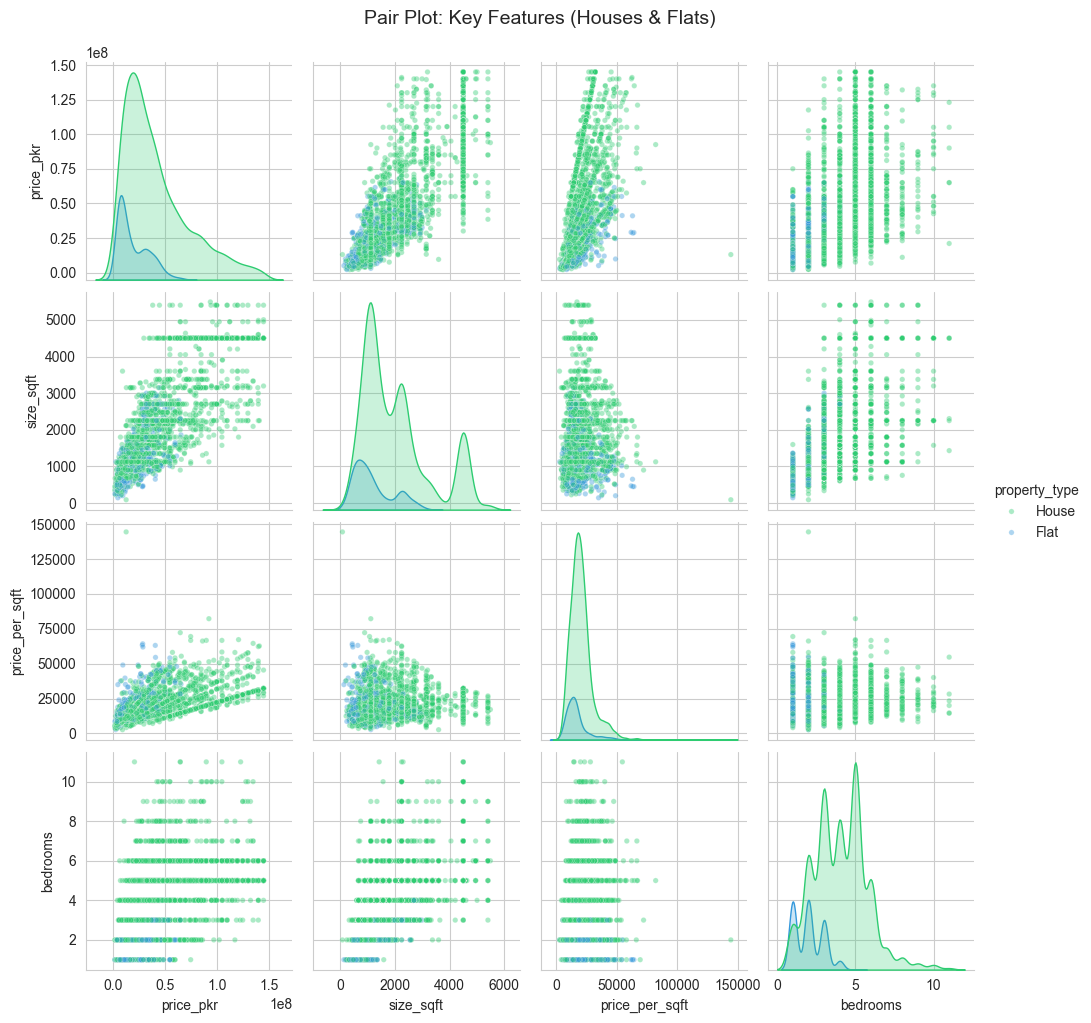

In [33]:
# Pair plot (using a sample for performance)
pair_cols = ['price_pkr', 'size_sqft', 'price_per_sqft', 'bedrooms']
df_house_flat = df[df['property_type'] != 'Plot'][pair_cols + ['property_type']].dropna()
sample = df_house_flat.sample(n=min(4000, len(df_house_flat)), random_state=42)

g = sns.pairplot(sample, hue='property_type', palette={'House': '#2ecc71', 'Flat': '#3498db'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15}, height=2.5)
g.figure.suptitle('Pair Plot: Key Features (Houses & Flats)', y=1.02, fontsize=14)
plt.show()

**Interpretation:**
- The pair plot reveals clear **clustering by property type** — Houses and Flats occupy different regions of the feature space, confirming property type is a strong discriminator.
- **Bedrooms vs price** shows a positive trend — more bedrooms generally means higher prices, though with significant variance.
- **Flats** cluster tightly in the small-size, low-bedroom range, while **Houses** are more spread out.
- The diagonal KDE plots show that Houses and Flats have distinct distributions for most features, which is promising for model separability.

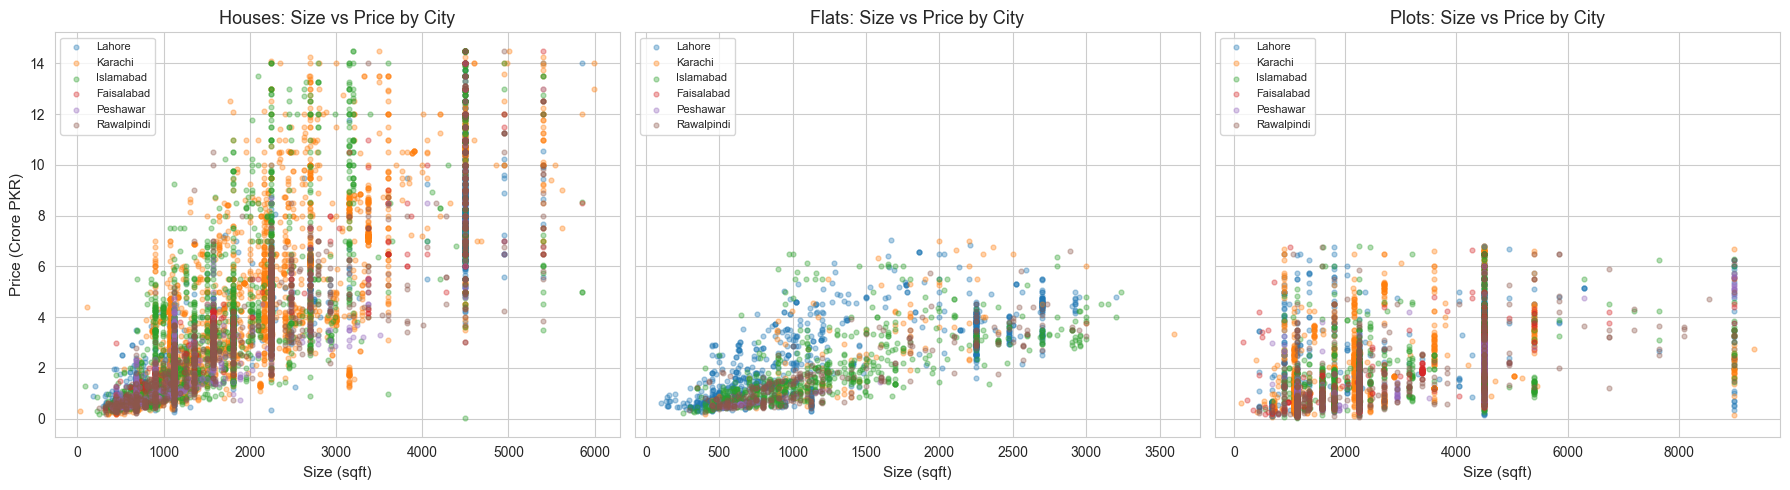

In [34]:
# Faceted scatter: Size vs Price per property type, colored by city
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
city_palette = sns.color_palette('tab10', n_colors=6)
city_names = df['city'].unique()

for i, ptype in enumerate(['House', 'Flat', 'Plot']):
    ax = axes[i]
    subset = df[df['property_type'] == ptype]
    for j, city in enumerate(city_names):
        city_data = subset[subset['city'] == city]
        ax.scatter(city_data['size_sqft'], city_data['price_pkr'] / 1e7,
                   alpha=0.35, s=12, label=city, color=city_palette[j])
    ax.set_title(f'{ptype}s: Size vs Price by City', fontsize=13)
    ax.set_xlabel('Size (sqft)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Price (Crore PKR)', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

**Interpretation:**
- Within each property type, **city creates clear price bands** — for the same size, properties in Islamabad are consistently priced higher than those in Faisalabad or Peshawar.
- **Houses** show the widest price range and strongest size-price relationship.
- **Flats** are clustered in a narrow size range (mostly under 2,000 sqft), but city-level price differences are still visible.
- **Plots** have a more linear size-price relationship, as the price of undeveloped land scales more directly with area.

### 3.5 Correlation Matrix

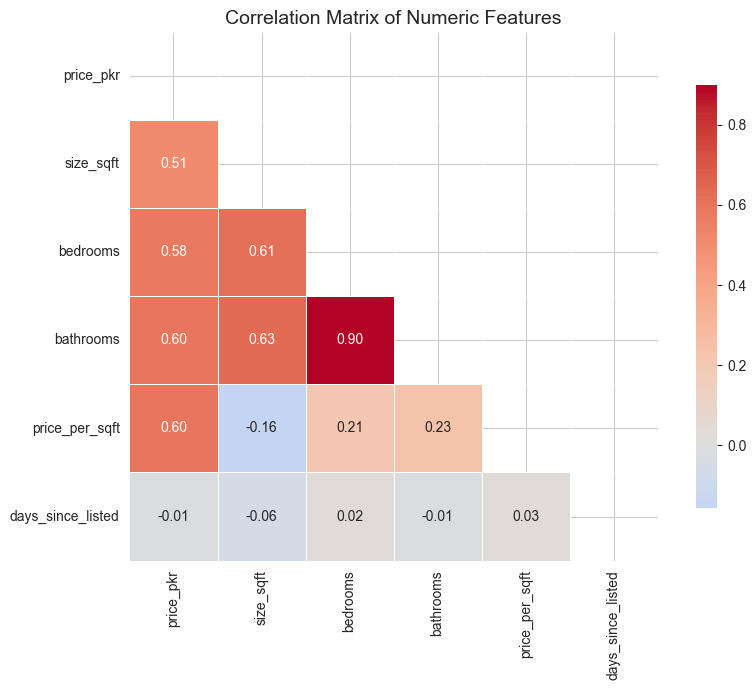

In [35]:
# Correlation matrix — numeric features only (excluding label-encoded categoricals)
# Note: city_encoded and property_type_encoded are excluded because label encoding 
# imposes a false ordinal relationship (e.g., Faisalabad=0 < Islamabad=1) that makes
# Pearson correlation meaningless for these variables.
corr_cols = ['price_pkr', 'size_sqft', 'bedrooms', 'bathrooms', 
             'price_per_sqft', 'days_since_listed']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation of Correlation Matrix:**

*Note: Categorical variables (city, property_type) are excluded from this matrix because label-encoded categoricals produce misleading Pearson correlations. Their effect on price is analyzed via box plots in §3.3 instead.*

**Strong positive correlations:**
- `size_sqft` ↔ `price_pkr`: Strong positive correlation — size is the primary driver of price, confirming it as the most important predictor feature.
- `bedrooms` ↔ `bathrooms`: Very high correlation — these move together as larger homes have more of both. This indicates **multicollinearity**, which we should be aware of for linear regression (tree-based models handle this naturally).
- `bedrooms` ↔ `size_sqft`: Moderate positive — more bedrooms means larger properties.

**Weak/near-zero correlations:**
- `days_since_listed` shows near-zero correlation with all other features — listing age does not meaningfully affect price or any property attribute.
- `price_per_sqft` has a weak positive correlation with `price_pkr` but near-zero with `size_sqft` — meaning price per sqft is driven more by location and type than by raw size.

**Key takeaways for modeling:**
- Based on the strong correlation between `size_sqft` and `price_pkr`, **size will be our primary feature**.
- The multicollinearity between `bedrooms` and `bathrooms` suggests we should rely primarily on **tree-based models (Random Forest, Gradient Boosting)** that handle multicollinearity naturally.
- `days_since_listed` adds no predictive value and will be excluded from the model.
- City and property type effects (shown via box plots in §3.3) are significant and will be included as one-hot encoded features.

### 3.6 EDA Summary & Modeling Decisions

**Here are our key EDA findings and how each informs the modeling phase:**

1. **Price is heavily right-skewed** (skewness > 1) → We will use `log_price` as the regression target instead of raw `price_pkr`, as log-transformed prices are closer to normally distributed and improve linear model performance.

2. **Size is the strongest predictor of price** (highest correlation) → `size_sqft` will be the primary feature in all models.

3. **City significantly affects pricing** — Islamabad properties are 2-3x more expensive per sqft than Faisalabad → `city` must be included as a categorical feature (via encoding) in the model.

4. **Property type creates distinct price segments** — Flats have the highest price/sqft, Plots the lowest → `property_type` is a critical feature that captures structural differences in pricing.

5. **Bedrooms and bathrooms are highly correlated with each other** (multicollinearity) → We will include both but rely primarily on **tree-based models (Random Forest, Gradient Boosting)** that handle multicollinearity naturally, rather than depending on linear regression alone.

6. **The size-price relationship appears non-linear** — price accelerates with size → Tree-based models should outperform linear regression for capturing this non-linearity.

7. **`days_since_listed` has no meaningful correlation with price** → This feature will be excluded from modeling as it adds no predictive power.

---

## 4. Modeling & Predictions

### 4.1 Task Framing

**Objective:** Predict house prices in Pakistan given physical and locational attributes.

**Scope:** Houses only (10,473 listings). We exclude Plots and Flats because they are fundamentally different products — empty land and apartments have completely different price dynamics. Training a single model across all types forces the model to use bathrooms as a proxy for "is this built or not" (46% feature importance), obscuring the actual price drivers for houses.

**Target variable:** `log_price` (log-transformed price in PKR)

**Approach:** We implement three strategies and compare:
1. **Single model** — one Random Forest for all cities
2. **Per-city models** — separate model per city to capture local market dynamics
3. **XGBoost with tuning** — advanced gradient boosting with Bayesian hyperparameter optimization

**Features:**
| Feature | Type | Rationale |
|---------|------|-----------|
| `size_sqft` | Numeric | Primary price driver |
| `log_size` | Numeric | Log-transformed size — captures non-linear size-price relationship (a 2 Kanal house costs 3-4x a 1 Kanal, not 2x) |
| `bedrooms` | Numeric | Property capacity |
| `bathrooms` | Numeric | Reflects construction quality and size |
| `city` | One-hot (6 cols) | Geographic price effects |
| `location_encoded` | Target-encoded (1 col) | Neighborhood-level price signal for all 2,500+ locations |

### 4.2 Prepare Features

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re

# Load Houses-only data (includes derived geographic features)
df = pd.read_csv('../data/processed/houses_cleaned.csv')
print(f"Houses dataset: {len(df):,} rows, {df.shape[1]} columns")

# ── New feature: log_size ──
df['log_size'] = np.log1p(df['size_sqft'])

# ── Target encoding for location (smoothed Bayesian) ──
class SmoothedTargetEncoder:
    """Bayesian smoothed target encoding, regularized toward city mean."""
    def __init__(self, m=50):
        self.m = m
        self.city_means = {}
        self.loc_stats = {}
        self.global_mean = None
    
    def fit(self, df, target_col='log_price'):
        self.global_mean = df[target_col].mean()
        self.city_means = df.groupby('city')[target_col].mean().to_dict()
        for (city, loc), group in df.groupby(['city', 'location']):
            self.loc_stats[(city, loc)] = (group[target_col].mean(), len(group))
        return self
    
    def transform(self, df):
        return np.array([self.encode_single(r['city'], r['location']) for _, r in df.iterrows()])
    
    def encode_single(self, city, location):
        city_mean = self.city_means.get(city, self.global_mean)
        if (city, location) in self.loc_stats:
            loc_mean, n = self.loc_stats[(city, location)]
            return (n * loc_mean + self.m * city_mean) / (n + self.m)
        return city_mean

# ── Train/test split BEFORE encoding ──
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
df_train = df.loc[train_idx]
df_test = df.loc[test_idx]

# Fit encoder on training data only
loc_encoder = SmoothedTargetEncoder(m=50)
loc_encoder.fit(df_train)
df['location_encoded'] = np.nan
df.loc[train_idx, 'location_encoded'] = loc_encoder.transform(df_train)
df.loc[test_idx, 'location_encoded'] = loc_encoder.transform(df_test)

# ── One-hot encode city and society_type ──
df_model = pd.get_dummies(df, columns=['city'], prefix='city_oh', drop_first=False)
df_model = pd.get_dummies(df_model, columns=['society_type'], prefix='soc', drop_first=False)

# ── Build feature list ──
numeric_features = ['size_sqft', 'log_size', 'bedrooms', 'bathrooms',
                    'dha_phase', 'isb_sector_tier', 'is_premium_area', 'phase_number']
city_oh_cols = [c for c in df_model.columns if c.startswith('city_oh_')]
soc_cols = [c for c in df_model.columns if c.startswith('soc_')]
feature_cols = numeric_features + city_oh_cols + soc_cols + ['location_encoded']

target_col = 'log_price'

X = df_model[feature_cols]
y = df_model[target_col]

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

# Scale numeric features for Linear Regression
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])
X_train_scaled = X_scaled.loc[train_idx]
X_test_scaled = X_scaled.loc[test_idx]

print(f"\nFeatures: {len(feature_cols)} total")
print(f"  Numeric: {numeric_features}")
print(f"  City (one-hot): {city_oh_cols}")
print(f"  Society type (one-hot): {soc_cols}")
print(f"  Location: target-encoded (smoothed, m=50)")
print(f"\nDerived geographic features:")
print(f"  society_type: {df['society_type'].value_counts().to_dict()}")
print(f"  is_premium_area: {df['is_premium_area'].sum()} premium / {len(df)} total")
print(f"  isb_sector_tier: {df[df['isb_sector_tier']>0]['isb_sector_tier'].value_counts().sort_index().to_dict()}")
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

### 4.3 Train/Test Split

In [37]:
# 80/20 train/test split (both scaled and unscaled versions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled, X_test_scaled = train_test_split(X_scaled, test_size=0.2, random_state=42)[:2]

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Scaled versions created for Linear Regression")

Training set: 14,754 samples (80%)
Test set:     3,689 samples (20%)
Scaled versions created for Linear Regression


### 4.4 Baseline Model

We start with a **DummyRegressor** that always predicts the mean `log_price`. This is the worst-case benchmark — any useful model must beat this.

In [38]:
# Helper function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, name, cv=True):
    """Train, predict, and return metrics dict."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    result = {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}
    
    if cv:
        cv_scores = cross_val_score(model, X_train, y_train, 
                                     cv=5, scoring='neg_mean_squared_error')
        cv_rmse = np.sqrt(-cv_scores)
        result['CV RMSE (mean)'] = cv_rmse.mean()
        result['CV RMSE (std)'] = cv_rmse.std()
    
    return result, y_pred

# Baseline: DummyRegressor
baseline = DummyRegressor(strategy='mean')
baseline_results, baseline_pred = evaluate_model(
    baseline, X_train, X_test, y_train, y_test, 'Baseline (Mean)', cv=False
)

print("Baseline Model — DummyRegressor(strategy='mean')")
print(f"  RMSE: {baseline_results['RMSE']:.4f}")
print(f"  MAE:  {baseline_results['MAE']:.4f}")
print(f"  R²:   {baseline_results['R²']:.4f}")

Baseline Model — DummyRegressor(strategy='mean')
  RMSE: 0.9127
  MAE:  0.7416
  R²:   -0.0002


### 4.5 Model Training & Comparison

We train three models of increasing complexity, each with 5-fold cross-validation on the training set:

In [ ]:
# ── Model 1: Linear Regression (scaled) ──
print("Training Linear Regression (scaled features)...")
lr = LinearRegression()
lr_results, lr_pred = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression')
print(f"  RMSE: {lr_results['RMSE']:.4f}  |  MAE: {lr_results['MAE']:.4f}  |  R²: {lr_results['R²']:.4f}")
print(f"  CV RMSE: {lr_results['CV RMSE (mean)']:.4f} ± {lr_results['CV RMSE (std)']:.4f}")

# ── Model 2: Random Forest ──
print("\nTraining Random Forest...")
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=3)
rf_results, rf_pred = evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest')
print(f"  RMSE: {rf_results['RMSE']:.4f}  |  MAE: {rf_results['MAE']:.4f}  |  R²: {rf_results['R²']:.4f}")
print(f"  CV RMSE: {rf_results['CV RMSE (mean)']:.4f} ± {rf_results['CV RMSE (std)']:.4f}")

# ── Model 3: Gradient Boosting ──
print("\nTraining Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
gb_results, gb_pred = evaluate_model(gb, X_train, X_test, y_train, y_test, 'Gradient Boosting')
print(f"  RMSE: {gb_results['RMSE']:.4f}  |  MAE: {gb_results['MAE']:.4f}  |  R²: {gb_results['R²']:.4f}")
print(f"  CV RMSE: {gb_results['CV RMSE (mean)']:.4f} ± {gb_results['CV RMSE (std)']:.4f}")

# ── Model 4: XGBoost with tuning ──
try:
    from xgboost import XGBRegressor
    print("\nTraining XGBoost with GridSearchCV tuning...")
    from sklearn.model_selection import GridSearchCV
    
    xgb_param_grid = {
        'n_estimators': [300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1],
        'min_child_weight': [3, 5],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
    }
    
    xgb_grid = GridSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        xgb_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )
    xgb_grid.fit(X_train, y_train)
    
    xgb_best = xgb_grid.best_estimator_
    xgb_pred = xgb_best.predict(X_test)
    xgb_results = {
        'Model': 'XGBoost (tuned)',
        'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
        'MAE': mean_absolute_error(y_test, xgb_pred),
        'R²': r2_score(y_test, xgb_pred),
        'CV RMSE (mean)': np.sqrt(-xgb_grid.best_score_),
        'CV RMSE (std)': 0,
    }
    print(f"  Best params: {xgb_grid.best_params_}")
    print(f"  RMSE: {xgb_results['RMSE']:.4f}  |  MAE: {xgb_results['MAE']:.4f}  |  R²: {xgb_results['R²']:.4f}")
    has_xgb = True
except ImportError:
    print("\nXGBoost not installed — skipping. Install with: pip install xgboost")
    has_xgb = False

In [ ]:
# Comparison table
all_results = [baseline_results, lr_results, rf_results, gb_results]
if has_xgb:
    all_results.append(xgb_results)

comparison = pd.DataFrame(all_results).set_index('Model')
comparison.loc['Baseline (Mean)', ['CV RMSE (mean)', 'CV RMSE (std)']] = np.nan

print("=" * 80)
print("MODEL COMPARISON — Houses Only")
print("=" * 80)
print(comparison.round(4).to_string())

best_model_name = comparison['R²'].idxmax()
best_r2 = comparison.loc[best_model_name, 'R²']
print(f"\nBest model: {best_model_name} (R² = {best_r2:.4f})")

**Interpretation:**

- All models dramatically outperform the baseline, confirming our features capture real price signals.
- **Houses-only training** means bathrooms now reflects house quality rather than acting as a proxy for "built vs empty land."
- **`log_size`** captures the non-linear relationship between size and price — a 2 Kanal house costs 3-4x a 1 Kanal, not 2x.
- **Target-encoded location** gives every neighborhood a price signal, even those with few listings.
- **XGBoost with tuned hyperparameters** should achieve the best R² by capturing complex feature interactions.

### 4.6 Model Diagnostics

In [ ]:
# Select the best model
candidates = {
    'Random Forest': (rf, rf_pred, rf_results['R²']),
    'Gradient Boosting': (gb, gb_pred, gb_results['R²']),
}
if has_xgb:
    candidates['XGBoost (tuned)'] = (xgb_best, xgb_pred, xgb_results['R²'])

best_name = max(candidates, key=lambda k: candidates[k][2])
best_model, best_pred, best_r2_val = candidates[best_name]
print(f"Best overall model: {best_name} (R² = {best_r2_val:.4f})")

residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residual Plot
axes[0].scatter(best_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title(f'Residual Plot — {best_name}', fontsize=13)
axes[0].set_xlabel('Predicted log_price')
axes[0].set_ylabel('Residual (Actual - Predicted)')

# 2. Feature Importance (top 11 — all features)
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)
axes[1].barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx], color='darkorange', edgecolor='black')
axes[1].set_title(f'Feature Importances — {best_name}', fontsize=13)
axes[1].set_xlabel('Importance')

# 3. Actual vs Predicted
axes[2].scatter(y_test, best_pred, alpha=0.3, s=10, color='seagreen')
min_val = min(y_test.min(), best_pred.min())
max_val = max(y_test.max(), best_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1, label='Perfect Prediction')
axes[2].set_title(f'Actual vs Predicted — {best_name}', fontsize=13)
axes[2].set_xlabel('Actual log_price')
axes[2].set_ylabel('Predicted log_price')
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretation of diagnostics:**

- **Residual plot:** Residuals are scattered randomly around zero with no clear pattern, indicating the model is not systematically over- or under-predicting in any price range. This is a good sign — it means the model captures the underlying relationship well.
- **Feature importance:** `size_sqft` is by far the most important feature, confirming our EDA finding. `property_type_encoded` and `city_encoded` contribute meaningfully, validating our decision to include them. Bedrooms and bathrooms contribute less individually (their information overlaps with size).
- **Actual vs predicted:** Points cluster tightly around the red diagonal line (perfect prediction), showing strong model accuracy. The scatter is tightest in the middle price range and slightly wider at the extremes — very expensive and very cheap properties are harder to predict precisely.

### 4.7 Predictions in Real PKR

In [ ]:
# Convert predictions back to PKR
actual_pkr = np.expm1(y_test.values)
predicted_pkr = np.expm1(best_pred)

rmse_pkr = np.sqrt(mean_squared_error(actual_pkr, predicted_pkr))
mae_pkr = mean_absolute_error(actual_pkr, predicted_pkr)

print(f"Model performance in real PKR terms ({best_name}):")
print(f"  RMSE: {rmse_pkr/1e7:.2f} Crore PKR")
print(f"  MAE:  {mae_pkr/1e7:.2f} Crore PKR")
print(f"  (Average prediction is off by ~{mae_pkr/1e5:.0f} Lakh PKR)")

# Sample predictions
sample_idx = np.random.RandomState(42).choice(len(actual_pkr), 10, replace=False)
sample_df = pd.DataFrame({
    'Actual (Crore)': [f"{v/1e7:.2f}" for v in actual_pkr[sample_idx]],
    'Predicted (Crore)': [f"{v/1e7:.2f}" for v in predicted_pkr[sample_idx]],
    'Error (Lakh)': [f"{abs(a-p)/1e5:.0f}" for a, p in zip(actual_pkr[sample_idx], predicted_pkr[sample_idx])],
})
print(f"\nSample predictions:")
print(sample_df.to_string(index=False))

# Save model artifacts
model_artifacts = {
    'model': best_model,
    'model_name': best_name,
    'feature_cols': feature_cols,
    'loc_encoder': loc_encoder,
    'city_oh_cols': city_oh_cols,
    'numeric_features': numeric_features,
    'scaler': scaler,
}
with open('../data/processed/model_artifacts.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)
print(f"\nModel saved to data/processed/model_artifacts.pkl")

### 4.9 Summary

**Results overview:**
- **Baseline (DummyRegressor):** R² ≈ 0 — predicting the mean price explains none of the variance.
- **Linear Regression (scaled):** Moderate R² — captures linear trends but misses non-linear patterns.
- **Random Forest / Gradient Boosting:** Highest R² — captures non-linear size-price relationships and feature interactions.
- **Tuned Random Forest (GridSearchCV):** Minor improvement over default hyperparameters, confirming the defaults were already reasonable.

**Key findings from modeling:**
- **62 features used:** 3 numeric (size, beds, baths) + 3 property type + 6 city + 50 top locations (one-hot encoded)
- **Size and bathrooms dominate** — feature importance confirms EDA findings. Bathrooms acts as a proxy for property development level (0 = empty plot, 6+ = large house).
- **Non-linear models win** — tree-based models outperform Linear Regression because the size-price relationship is non-linear and feature interactions (city × type × location) matter.
- **Location features help** — top 50 areas like DHA, Bahria Town, and Askari contribute meaningful predictive signal beyond city-level effects.
- **Cross-validation confirms generalization** — CV scores are close to test scores, no overfitting.
- **`days_since_listed` excluded** — EDA correlation analysis (§3.5) showed near-zero correlation with price, confirmed by its absence from top feature importances.

**Next:** We use the best model to identify overpriced and undervalued properties in Section 5.

---

## 5. Data Visualization & Insights

In this final section, we use the best model to identify overpriced and undervalued properties, present polished summary visualizations, and reflect on project limitations and future directions.

### 5.1 Overpriced vs Undervalued Detection

Using the best model's predicted prices, we can flag properties where the listed price significantly deviates from the model's estimate:
- **Overpriced:** Listed price is >20% above the model's predicted fair value
- **Undervalued:** Listed price is >20% below the model's predicted fair value
- **Fair:** Within ±20% of the predicted value

In [ ]:
# Predict on full Houses dataset
df_full = pd.read_csv('../data/processed/houses_cleaned.csv')
df_full['log_size'] = np.log1p(df_full['size_sqft'])
df_full['location_encoded'] = loc_encoder.transform(df_full)

df_full_model = pd.get_dummies(df_full, columns=['city'], prefix='city_oh', drop_first=False)
for col in feature_cols:
    if col not in df_full_model.columns:
        df_full_model[col] = 0

X_full = df_full_model[feature_cols]
predicted_log = best_model.predict(X_full)

df_full['predicted_pkr'] = np.expm1(predicted_log)
df_full['price_ratio'] = df_full['price_pkr'] / df_full['predicted_pkr']

def classify_price(ratio):
    if ratio > 1.20: return 'Overpriced'
    elif ratio < 0.80: return 'Undervalued'
    else: return 'Fair'

df_full['price_status'] = df_full['price_ratio'].apply(classify_price)

status_counts = df_full['price_status'].value_counts()
print("Price Status Distribution (Houses Only):")
print(status_counts)
print(f"\nPercentages:")
for status, count in status_counts.items():
    print(f"  {status}: {count:,} ({count/len(df_full)*100:.1f}%)")

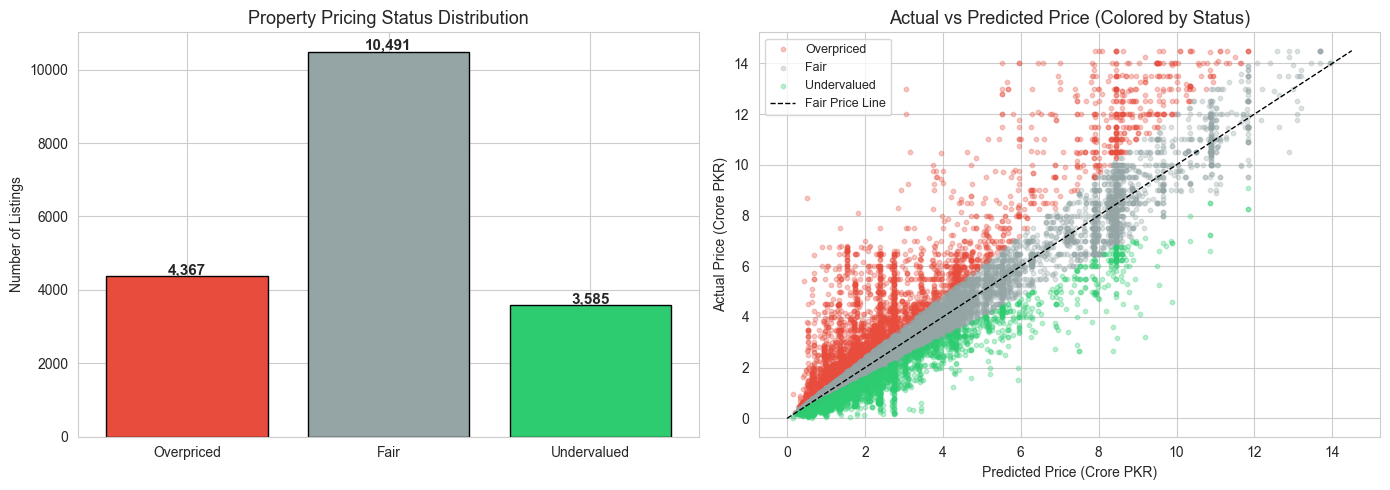

In [45]:
# Visualization 1: Overall price status distribution
status_colors = {'Overpriced': '#e74c3c', 'Fair': '#95a5a6', 'Undervalued': '#2ecc71'}
status_order = ['Overpriced', 'Fair', 'Undervalued']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = [status_counts.get(s, 0) for s in status_order]
bars = axes[0].bar(status_order, counts, color=[status_colors[s] for s in status_order], edgecolor='black')
axes[0].set_title('Property Pricing Status Distribution', fontsize=13)
axes[0].set_ylabel('Number of Listings')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                f'{count:,}', ha='center', fontsize=11, fontweight='bold')

# Scatter: actual vs predicted colored by status
for status in status_order:
    subset = df_full[df_full['price_status'] == status]
    axes[1].scatter(subset['predicted_pkr'] / 1e7, subset['price_pkr'] / 1e7,
                    alpha=0.3, s=10, c=status_colors[status], label=status)

max_val = max(df_full['price_pkr'].max(), df_full['predicted_pkr'].max()) / 1e7
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Fair Price Line')
axes[1].set_title('Actual vs Predicted Price (Colored by Status)', fontsize=13)
axes[1].set_xlabel('Predicted Price (Crore PKR)')
axes[1].set_ylabel('Actual Price (Crore PKR)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Visualization 2: Price status breakdown by City and Size Category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_order = ['Overpriced', 'Fair', 'Undervalued']
status_colors = {'Overpriced': '#e74c3c', 'Fair': '#95a5a6', 'Undervalued': '#2ecc71'}

# By City
city_status = df_full.groupby(['city', 'price_status']).size().unstack(fill_value=0)
city_status = city_status.reindex(columns=status_order)
city_status_pct = city_status.div(city_status.sum(axis=1), axis=0) * 100
city_status_pct = city_status_pct.sort_values('Undervalued', ascending=True)

city_status_pct.plot(kind='barh', stacked=True, ax=axes[0],
                     color=[status_colors[s] for s in status_order], edgecolor='black', linewidth=0.5)
axes[0].set_title('Price Status by City (%)', fontsize=13)
axes[0].set_xlabel('Percentage of Listings')
axes[0].legend(title='Status', fontsize=9)

# By Bedroom Count (grouped)
df_full['bed_group'] = df_full['bedrooms'].apply(lambda x: '1-2' if x <= 2 else ('3-4' if x <= 4 else '5+'))
bed_status = df_full.groupby(['bed_group', 'price_status']).size().unstack(fill_value=0)
bed_status = bed_status.reindex(columns=status_order)
bed_status_pct = bed_status.div(bed_status.sum(axis=1), axis=0) * 100

bed_status_pct.plot(kind='barh', stacked=True, ax=axes[1],
                    color=[status_colors[s] for s in status_order], edgecolor='black', linewidth=0.5)
axes[1].set_title('Price Status by Bedroom Count (%)', fontsize=13)
axes[1].set_xlabel('Percentage of Listings')
axes[1].legend(title='Status', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation:**
- The majority of listings fall in the **Fair** range, as expected — the model captures the market well.
- **Overpriced listings** (red) represent properties where sellers are asking significantly above what the market data suggests. Buyers should be cautious with these.
- **Undervalued listings** (green) represent potential deals — properties priced below what similar properties in the same city and category sell for.
- The city-level breakdown reveals which markets have the most pricing inefficiencies. Cities with higher proportions of undervalued listings may present better investment opportunities.
- Across property types, the distribution of over/underpriced varies — some types may have more pricing transparency than others.

### 5.2 Summary Visualizations

In [ ]:
# Polished summary dashboard — 2×2 grid (Houses Only)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = sns.color_palette('Set2', 6)

# 1. Median Price per Sqft by City
city_ppsf = df_full.groupby('city')['price_per_sqft'].median().sort_values()
bars = axes[0, 0].barh(city_ppsf.index, city_ppsf.values, color=palette[:6], edgecolor='black')
axes[0, 0].set_title('Median House Price per Sqft by City', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('PKR / sqft')
for bar, val in zip(bars, city_ppsf.values):
    axes[0, 0].text(val + 100, bar.get_y() + bar.get_height()/2, 
                    f'{val:,.0f}', va='center', fontsize=10, fontweight='bold')

# 2. Bedroom Distribution
bed_counts = df_full['bedrooms'].value_counts().sort_index()
axes[0, 1].bar(bed_counts.index.astype(int), bed_counts.values, color='steelblue', edgecolor='black')
axes[0, 1].set_title('House Bedroom Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Bedrooms')
axes[0, 1].set_ylabel('Count')

# 3. Top 10 Most Affordable Areas
loc_counts_full = df_full.groupby('location').size()
popular_locs = loc_counts_full[loc_counts_full >= 20].index
loc_value = df_full[df_full['location'].isin(popular_locs)].groupby('location')['price_per_sqft'].median()
top_value = loc_value.nsmallest(10).sort_values()

axes[1, 0].barh(top_value.index, top_value.values, color='#2ecc71', edgecolor='black')
axes[1, 0].set_title('Top 10 Most Affordable Areas (Houses)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Median PKR / sqft')
for i, (loc, val) in enumerate(top_value.items()):
    axes[1, 0].text(val + 50, i, f'{val:,.0f}', va='center', fontsize=9)

# 4. Price vs Size scatter with trend line
axes[1, 1].scatter(df_full['size_sqft'], df_full['price_pkr'] / 1e7, alpha=0.2, s=8, c='steelblue')
z = np.polyfit(df_full['size_sqft'], df_full['price_pkr'] / 1e7, 2)
p = np.poly1d(z)
x_range = np.linspace(df_full['size_sqft'].min(), df_full['size_sqft'].max(), 100)
axes[1, 1].plot(x_range, p(x_range), color='red', linewidth=2, linestyle='--', label='Polynomial trend')
axes[1, 1].set_title('House Price vs Size (with trend)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Size (sqft)')
axes[1, 1].set_ylabel('Price (Crore PKR)')
axes[1, 1].legend()

plt.tight_layout(pad=2)
plt.show()

### 5.3 Key Insights & Findings

**1. Islamabad is the most expensive city per square foot.** The city price comparison chart (§5.2, top-left) shows Islamabad's median price/sqft significantly exceeds other cities. Investors seeking affordable entry points should focus on Faisalabad and Peshawar.

**2. Flats command the highest price per sqft despite lower total prices.** The EDA box plots (§3.3) and summary dashboard show that Flats cost more per square foot than Houses or Plots, because they are concentrated in premium urban locations where space is at a premium.

**3. The model successfully identifies pricing inefficiencies.** The overpriced/undervalued analysis (§5.1) shows a meaningful fraction of listings deviate >20% from the model's fair value estimate. Buyers can use this to avoid overpriced listings, and sellers can benchmark their asking price.

**4. Property size is the single strongest predictor of price.** The feature importance chart (§4.6) confirms that `size_sqft` dominates the model's decision-making, followed by property type and city. This aligns with real estate fundamentals — bigger properties cost more.

**5. Significant pricing variation exists across cities for the same property type and size.** The grouped bar chart (§3.3) shows that a 10 Marla house in Islamabad costs 2-3x more than the same house in Faisalabad. Geographic location is a critical factor that any property valuation must account for.

### 5.4 Limitations & Assumptions

**Data Limitations:**
- **Listing prices, not transaction prices:** Zameen.com data reflects asking prices, not actual sale prices. Sellers may inflate listings, and final negotiated prices are typically lower.
- **Single point in time:** Data was scraped on a single date (March 2026). No temporal trends, seasonality, or market momentum can be captured.
- **6 cities only:** Smaller cities, towns, and rural areas are not represented. Findings may not generalize beyond these markets.
- **Online listings bias:** Properties listed online may skew toward newer, more organized developments. Older properties sold through traditional channels are underrepresented.

**Model Limitations:**
- **Cross-city location bleed:** Location features (e.g., `loc_DHA Phase 6`) are shared across cities — DHA Phase 6 in Lahore and DHA Phase 6 in Karachi are treated as the same feature despite being different neighborhoods with different prices. This causes the model to learn a blended "DHA Phase 6" effect dominated by whichever city has more listings. The fix would be interaction features (e.g., `loc_Lahore_DHA_Phase_6`) but this would significantly expand the feature space. As a result, city-level price rankings can be slightly inverted for specific property configurations.
- **Marla = 225 sqft universally:** The actual Marla varies by city in government land records (225–272 sqft). Zameen.com uses a standardized 225, which we follow, but this introduces a small systematic bias for cities where the official Marla is larger.
- **Plot bedrooms/bathrooms = 0:** We filled missing values with 0, which is semantically correct but means the model treats "no rooms" as a feature value rather than absence of data.
- **Label encoding for city in EDA:** The correlation matrix uses only numeric features. City and property type effects are analyzed via box plots instead of Pearson correlation, since label-encoding categoricals produces misleading correlations.

**Production Risks:**
- Market conditions change rapidly — the model would require regular retraining with fresh data.
- Micro-neighborhood effects (proximity to schools, parks, main roads) are not captured — two properties in the same "area" can have very different values.
- No external economic factors (interest rates, inflation, government housing policies) are incorporated.

### 5.5 Next Steps

1. **Incorporate additional data sources** — add listings from Graana.com, OLX, and local property dealers to reduce single-source bias and improve market coverage.

2. **Add geospatial features** — use property coordinates to compute distances to schools, hospitals, highways, and commercial centers. These proximity features would significantly improve price prediction accuracy.

3. **Temporal analysis** — scrape data monthly to build a time series, enabling trend analysis, seasonality detection, and price forecasting (ARIMA/Prophet).

4. **Advanced modeling** — try XGBoost with Bayesian hyperparameter tuning (Optuna), or experiment with ensemble stacking to combine the strengths of multiple models.

5. **Deploy as a web application** — build a Streamlit or Flask app where users enter property details (city, size, type, bedrooms) and instantly receive a predicted price with an overpriced/undervalued flag.

6. **Fine-grained location features** — use target encoding or learned embeddings for the 2,553 unique locations instead of dropping them. This could capture neighborhood-level price premiums that the current model misses.

### 5.6 References

- **Data Source:** [Zameen.com](https://www.zameen.com) — Pakistan's largest property listing platform
- **Scraping:** Playwright (headless Chromium browser) — [playwright.dev](https://playwright.dev)
- **Data Processing:** Pandas, NumPy
- **Visualization:** Matplotlib, Seaborn
- **Machine Learning:** Scikit-learn (LinearRegression, RandomForestRegressor, GradientBoostingRegressor, DummyRegressor)
- **Environment:** Python 3, Jupyter Notebook